# F3-E - Estratégia E: Representação Intermediária com R1 e R2

Este notebook executa a Estratégia E da Fase 3. A tradução é decomposta em dois estágios, e cada estágio utiliza demonstrações enriquecidas com uma justificativa específica produzida e validada na F2:

```text
primeiro estágio:  NL + R1 → IR
segundo estágio:   IR gerada + R2 → Nile
```

R1 explica, nas demonstrações de treino, como a intenção em linguagem natural é organizada nos campos da Representação Intermediária. R2 explica como esses campos são compostos na expressão Nile. As justificativas do exemplo de teste nunca são fornecidas ao modelo aluno.

A F3-E avalia duas variantes sobre as mesmas 450 combinações experimentais:

```text
sem_ac:       NL + R1 → IR + R2 → Nile
primeira_ac:  NL + R1 → IR + R2 → Nile → primeira autocorreção, somente quando PSR=0
```

Não existe zero-shot nesta estratégia. A grade contém:

```text
k=1, k=3 e k=5
seleção Aleatória, Lexical e Semântica
5 folds × 10 exemplos de teste
```

Assim, são executados 450 fluxos-base e produzidos 900 registros finais:

```text
9 condições sem autocorreção × 50 exemplos = 450 registros
9 condições com primeira autocorreção × 50 exemplos = 450 registros
```

A IR do teste é sempre gerada pelo Qwen2.5-1.5B-Instruct no primeiro estágio. A IR de referência da F1 é usada somente para validação externa e nunca substitui uma saída inválida. O segundo estágio recebe exatamente a IR produzida pelo modelo, acompanhada somente pelas demonstrações de treino enriquecidas com R2.

A primeira autocorreção atua apenas sobre a Nile inicial rejeitada sintaticamente. A IR não é corrigida, regenerada nem substituída. O prompt de autocorreção recebe a IR gerada, a Nile rejeitada, o feedback do parser e as mesmas demonstrações enriquecidas com R2, sem expor a IR, a Nile, R1 ou R2 de referência do teste.

A cadeia principal é:

```text
entrada em linguagem natural
        ↓
prompt NL + R1 → IR com demonstrações de treino
        ↓
IR gerada pelo modelo aluno
        ↓
validação determinística pelo JSON Schema
        ↓
prompt IR gerada + R2 → Nile com demonstrações de treino
        ↓
Nile inicial
        ├── variante sem_ac: avaliar diretamente
        │
        └── variante primeira_ac:
                PSR=1 → preservar
                PSR=0 → corrigir com feedback do parser
        ↓
PSR, EM, ED, NED, SLA-S e SLA-F
        ↓
f3e_traducao_com_r1_r2.zip
```

As demonstrações são selecionadas exclusivamente no treino do fold. O F3-modelo já excluiu o próprio ID do teste, saídas Nile e IR idênticas e exemplos formalmente equivalentes. Em todas as tabelas e gráficos, os métodos aparecem na ordem Aleatória, Lexical e Semântica.

| Bloco | Etapa | Função metodológica | Resultado principal |
|---:|---|---|---|
| 1 | Configuração | Fixar estratégia, variantes, caminhos e padrão visual | Ambiente da F3-E |
| 2 | Auditoria da entrada | Localizar e verificar o F3-modelo | Base operacional íntegra |
| 3 | Carga integrada | Ativar CAMPI, IR, R1, R2, métricas, folds e seleções | Recursos comuns carregados |
| 4 | Plano | Construir os 450 fluxos-base | `f3e_plano_execucao.csv` |
| 5 | Modelo aluno | Carregar o Qwen2.5-1.5B-Instruct | Modelo pronto |
| 6 | NL + R1 → IR | Montar, auditar, executar e validar 450 IRs | IRs geradas e auditadas |
| 7 | IR + R2 → Nile | Montar, auditar e executar 450 traduções Nile | Variante `sem_ac` |
| 8 | Primeira autocorreção | Corrigir somente as Nile com PSR=0 e consolidar 900 resultados | Variantes finais |
| 9 | Análise | Produzir resumos, comparações e doze gráficos padronizados | Resultados interpretáveis |
| 10 | Empacotamento | Aplicar barreiras finais, manifesto e ZIP | Pacote operacional da F3-E |

## Bloco 1 - Configuração inicial

### Objetivo

Este bloco prepara o ambiente da F3-E e centraliza todas as decisões que devem permanecer fixas durante a execução. A configuração separa os 450 fluxos-base dos 900 registros finais, porque cada fluxo gera uma saída sem autocorreção e uma saída correspondente à primeira autocorreção.

### Configurações principais

O bloco define:

- estratégia `F3-E`;
- variantes `sem_ac` e `primeira_ac`;
- conjunto CAMPI com 50 exemplos e cinco folds;
- nove condições por variante e dezoito condições finais;
- `k=1`, `k=3` e `k=5`;
- métodos Aleatória, Lexical e Semântica;
- 450 fluxos-base e 900 registros finais;
- máximo de 512 novos tokens para IR;
- máximo de 256 novos tokens para Nile e autocorreção;
- geração determinística, sem amostragem;
- checkpoints independentes para IR, Nile e autocorreção;
- retomada por fingerprint e modo de teste rápido.

### Artefatos finais

Os caminhos dos planos, prompts, auditorias, gerações, validações, resultados, comparações, gráficos, manifesto e ZIP são definidos antes da execução. Os checkpoints permanecem fora do pacote final.

### Reprodutibilidade

Cada geração recebe uma semente derivada da semente global, do estágio, do fold, do ID, do método e de `k`. O fingerprint incorpora o prompt, o modelo e o limite de saída, impedindo a reutilização de uma resposta produzida por configuração incompatível.

### Padrão visual

As tabelas seguem o padrão das fases anteriores. Os tempos são armazenados em segundos nos artefatos computacionais e apresentados no notebook em horas, minutos e segundos. Os gráficos usam escalas fixas para permitir comparação direta entre estratégias.

### Resultado esperado

O ambiente estará preparado, sem carregar dados ou o modelo. O Bloco 1 não apresenta tabelas.

In [1]:
# ----------------------------------------------------------
# 1.1 Importação das bibliotecas principais
# ----------------------------------------------------------

import gc
import gzip
import hashlib
import importlib.metadata
import json
import os
import platform
import re
import shutil
import sys
import time
import traceback
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display


# ----------------------------------------------------------
# 1.2 Identificação da estratégia
# ----------------------------------------------------------

FASE = "F3-E"
ESTRATEGIA = "F3-E"
VARIANTES = ["sem_ac", "primeira_ac"]
NOME_ESTRATEGIA = "Tradução por Representação Intermediária com R1 e R2"
DATASET = "CAMPI"

TOTAL_EXEMPLOS_ESPERADO = 50
TOTAL_FOLDS_ESPERADO = 5
TOTAL_CONDICOES_BASE = 9
TOTAL_CONDICOES_ESPERADO = 18
TOTAL_FLUXOS_BASE_ESPERADO = 450
TOTAL_REGISTROS_ESPERADO = 900
SEED_GLOBAL = 42

K_FEWSHOT = [1, 3, 5]
VALORES_K = [1, 3, 5]
METODOS_FEWSHOT = [
    "random_seed42",
    "lexical_tfidf",
    "semantic_embeddings",
]

ORDEM_METODOS_EXIBICAO = [
    "random_seed42",
    "lexical_tfidf",
    "semantic_embeddings",
]
ORDEM_METODOS_MAPA = {
    metodo: posicao
    for posicao, metodo in enumerate(ORDEM_METODOS_EXIBICAO)
}

ORDEM_VARIANTES_EXIBICAO = ["sem_ac", "primeira_ac"]
ORDEM_VARIANTES_MAPA = {
    variante: posicao
    for posicao, variante in enumerate(ORDEM_VARIANTES_EXIBICAO)
}

ROTULOS_VARIANTES = {
    "sem_ac": "Sem autocorreção",
    "primeira_ac": "Primeira autocorreção",
}

ROTULOS_METODOS = {
    "random_seed42": "Aleatória",
    "lexical_tfidf": "Lexical",
    "semantic_embeddings": "Semântica",
}

CORES_METODOS = {
    "random_seed42": "#f2c94c",
    "lexical_tfidf": "#2ca02c",
    "semantic_embeddings": "#1f77b4",
}

METRICAS = ["psr", "em", "ed", "ned", "sla_s", "sla_f"]
ROTULOS_METRICAS = {
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}

AUTOCORRIGIR_APENAS_SINTATICAMENTE_INVALIDAS = True


# ----------------------------------------------------------
# 1.3 Modelo aluno e geração
# ----------------------------------------------------------

MODELO_ALUNO = "Qwen2.5-1.5B-Instruct"
MODELO_HF_ID = "Qwen/Qwen2.5-1.5B-Instruct"
MODELO_LOCAL_HINTS = ["qwen2.5", "1.5b", "instruct"]

USAR_CUDA = True
PERMITIR_DOWNLOAD_HUGGINGFACE = True
MAX_NEW_TOKENS_IR = 512
MAX_NEW_TOKENS_NILE = 256
DO_SAMPLE = False
LIMITE_CONTEXTO_FALLBACK = 32768


# ----------------------------------------------------------
# 1.4 Controle de execução
# ----------------------------------------------------------

REINICIAR_EXECUCAO = False
MODO_TESTE_RAPIDO = False
TOTAL_REGISTROS_TESTE_RAPIDO = 5
INTERVALO_SNAPSHOT = 25


# ----------------------------------------------------------
# 1.5 Diretórios principais
# ----------------------------------------------------------

KAGGLE_INPUT = Path("/kaggle/input")
RAIZ_TRABALHO = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path("/mnt/data/f3e_working")
)

F3E_DIR = RAIZ_TRABALHO / "f3e_traducao_com_r1_r2"
ENTRADAS_DIR = F3E_DIR / "entradas"
INTERMEDIARIOS_DIR = F3E_DIR / "intermediarios"
GRAFICOS_DIR = F3E_DIR / "graficos"
PACOTE_DIR = F3E_DIR / "pacote"
F3_MODELO_DIR = ENTRADAS_DIR / "f3_modelo_operacional"

if REINICIAR_EXECUCAO and F3E_DIR.exists():
    shutil.rmtree(F3E_DIR)

for diretorio in [
    F3E_DIR,
    ENTRADAS_DIR,
    INTERMEDIARIOS_DIR,
    GRAFICOS_DIR,
    PACOTE_DIR,
]:
    diretorio.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------
# 1.6 Caminhos dos artefatos da F3-E
# ----------------------------------------------------------

CONFIG_PATH = PACOTE_DIR / "f3e_config.json"
PLANO_PATH = PACOTE_DIR / "f3e_plano_execucao.csv"

PROMPTS_IR_PATH = PACOTE_DIR / "f3e_prompts_ir.jsonl.gz"
TOKEN_AUDIT_IR_PATH = PACOTE_DIR / "f3e_token_audit_ir.csv"
CHECKPOINT_IR_PATH = INTERMEDIARIOS_DIR / "f3e_checkpoint_ir.jsonl"
GENERATIONS_IR_PATH = PACOTE_DIR / "f3e_generations_ir.jsonl.gz"
IR_VALIDATION_PATH = PACOTE_DIR / "f3e_ir_validation.csv"

PROMPTS_NILE_PATH = PACOTE_DIR / "f3e_prompts_nile.jsonl.gz"
TOKEN_AUDIT_NILE_PATH = PACOTE_DIR / "f3e_token_audit_nile.csv"
CHECKPOINT_NILE_PATH = INTERMEDIARIOS_DIR / "f3e_checkpoint_nile.jsonl"
GENERATIONS_NILE_PATH = PACOTE_DIR / "f3e_generations_nile.jsonl.gz"
INITIAL_EVALUATION_PATH = PACOTE_DIR / "f3e_initial_evaluation.csv"

PROMPTS_AC_PATH = PACOTE_DIR / "f3e_prompts_autocorrection.jsonl.gz"
TOKEN_AUDIT_AC_PATH = PACOTE_DIR / "f3e_token_audit_autocorrection.csv"
CHECKPOINT_AC_PATH = INTERMEDIARIOS_DIR / "f3e_checkpoint_autocorrection.jsonl"
GENERATIONS_AC_PATH = PACOTE_DIR / "f3e_generations_autocorrection.jsonl.gz"
PROMPT_AUDIT_PATH = PACOTE_DIR / "f3e_prompt_audit.csv"

RESULTS_JSONL_PATH = PACOTE_DIR / "f3e_results.jsonl"
RESULTS_CSV_PATH = PACOTE_DIR / "f3e_results.csv"
SUMMARY_PATH = PACOTE_DIR / "f3e_summary.csv"
SUMMARY_FOLD_PATH = PACOTE_DIR / "f3e_summary_by_fold.csv"
IR_SUMMARY_PATH = PACOTE_DIR / "f3e_ir_summary.csv"
INVALID_SEM_AC_PATH = PACOTE_DIR / "f3e_invalid_outputs_sem_ac.csv"
INVALID_PRIMEIRA_AC_PATH = PACOTE_DIR / "f3e_invalid_outputs_primeira_ac.csv"
FINAL_AC_ELIGIBLE_PATH = PACOTE_DIR / "f3e_final_autocorrection_eligible.csv"
ANALYSIS_EXAMPLE_PATH = PACOTE_DIR / "f3e_analysis_by_example.csv"
EXECUTION_AUDIT_PATH = PACOTE_DIR / "f3e_execution_audit.csv"
COMPARISON_PATH = PACOTE_DIR / "f3e_comparison_sem_ac.csv"
GAINS_PATH = PACOTE_DIR / "f3e_gains.csv"
MANIFEST_PATH = PACOTE_DIR / "manifest.json"
ZIP_FINAL_PATH = RAIZ_TRABALHO / "f3e_traducao_com_r1_r2.zip"


# ----------------------------------------------------------
# 1.7 Funções de leitura, escrita e hashing
# ----------------------------------------------------------

def canonical_json(data):
    return json.dumps(
        data,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    )


def sha256_text(text):
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()


def sha256_file(path, chunk_size=1024 * 1024):
    path = Path(path)
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as handle:
        return json.load(handle)


def json_safe(data):
    if isinstance(data, dict):
        return {str(key): json_safe(value) for key, value in data.items()}
    if isinstance(data, (list, tuple)):
        return [json_safe(value) for value in data]
    if isinstance(data, np.generic):
        return json_safe(data.item())
    if isinstance(data, float) and not np.isfinite(data):
        return None
    return data


def write_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(json_safe(data), handle, ensure_ascii=False, indent=2, allow_nan=False)
        handle.write("\n")


def read_jsonl(path):
    records = []
    path = Path(path)
    if not path.exists():
        return records
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rt", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"JSONL inválido em {path}, linha {line_number}: {exc}"
                ) from exc
            if not isinstance(record, dict):
                raise TypeError(
                    f"Registro não é objeto em {path}, linha {line_number}."
                )
            records.append(record)
    return records


def write_jsonl(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
            handle.write("\n")


def append_jsonl(record, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
        handle.write("\n")
        handle.flush()
        os.fsync(handle.fileno())


def write_jsonl_gz(records, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with gzip.open(path, "wt", encoding="utf-8") as handle:
        for record in records:
            handle.write(json.dumps(record, ensure_ascii=False, separators=(",", ":")))
            handle.write("\n")


def package_version(name):
    try:
        return importlib.metadata.version(name)
    except Exception:
        return None


def clean_runtime_caches(root):
    root = Path(root)
    for cache in root.rglob("__pycache__"):
        if cache.is_dir():
            shutil.rmtree(cache, ignore_errors=True)
    for suffix in ("*.pyc", "*.pyo"):
        for item in root.rglob(suffix):
            item.unlink(missing_ok=True)


# ----------------------------------------------------------
# 1.8 Padrão visual das tabelas
# ----------------------------------------------------------

CONTADOR_TABELAS = 0

ROTULOS_COLUNAS = {
    "execution_id": "ID da execução",
    "fold": "fold",
    "id": "ID",
    "test_id": "ID de teste",
    "strategy": "estratégia",
    "variant": "variante",
    "stage": "etapa",
    "pipeline_id": "ID do fluxo",
    "ir_valid": "validade da IR",
    "ir_extracted": "IR extraída",
    "eligible_for_autocorrection": "elegível à autocorreção",
    "autocorrection_applied": "autocorreção aplicada",
    "regime": "regime",
    "selection_method": "método de seleção",
    "selection_label": "rótulo do método",
    "k": "k",
    "records": "registros",
    "total": "total",
    "status": "status",
    "item": "item",
    "value": "valor",
    "file": "arquivo",
    "path": "caminho",
    "size_bytes": "tamanho em bytes",
    "sha256": "SHA-256",
    "prompt_tokens": "tokens do prompt",
    "generated_tokens": "tokens gerados",
    "elapsed_seconds": "tempo decorrido",
    "elapsed_primary_seconds": "tempo médio NL + R1 → IR",
    "elapsed_secondary_seconds": "tempo médio IR + R2 → Nile",
    "elapsed_autocorrection_seconds": "tempo médio de autocorreção",
    "syntax_valid": "validade sintática",
    "psr": "PSR",
    "em": "EM",
    "ed": "ED",
    "ned": "NED",
    "sla_s": "SLA-S",
    "sla_f": "SLA-F",
}


def _display_value(value):
    if isinstance(value, (bool, np.bool_)):
        return "sim" if value else "não"
    if value is None:
        return "-"
    try:
        if not isinstance(value, str) and pd.isna(value):
            return "-"
    except Exception:
        pass
    return value


def formatar_duracao(segundos):
    if segundos is None:
        return "-"

    try:
        if pd.isna(segundos):
            return "-"
    except Exception:
        pass

    total_segundos = max(
        0,
        int(round(float(segundos))),
    )
    horas, restante = divmod(total_segundos, 3600)
    minutos, segundos_restantes = divmod(restante, 60)

    if horas > 0:
        return (
            f"{horas:02d}h "
            f"{minutos:02d}min "
            f"{segundos_restantes:02d}s"
        )

    if minutos > 0:
        return (
            f"{minutos:02d}min "
            f"{segundos_restantes:02d}s"
        )

    return f"{segundos_restantes:02d}s"


def exibir_tabela(df, titulo=None, altura_px=None, mostrar_indice=False):
    global CONTADOR_TABELAS
    if df is None:
        print("Tabela não disponível.")
        return
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)
    if df.empty:
        print("Tabela vazia.")
        return

    CONTADOR_TABELAS += 1
    tabela = df.copy()
    for coluna in tabela.columns:
        if str(coluna).endswith("_seconds"):
            tabela[coluna] = tabela[coluna].apply(formatar_duracao)
        else:
            tabela[coluna] = tabela[coluna].apply(_display_value)
    tabela = tabela.rename(
        columns={
            coluna: ROTULOS_COLUNAS.get(coluna, str(coluna).replace("_", " "))
            for coluna in tabela.columns
        }
    )

    titulo_final = f"Tabela {CONTADOR_TABELAS}"
    if titulo:
        titulo_final += f". {titulo}"

    html_tabela = tabela.to_html(
        escape=True,
        index=mostrar_indice,
        border=0,
        justify="left",
        classes="tabela_saida",
    )
    altura_css = (
        "overflow-y: visible;"
        if altura_px is None
        else f"max-height: {altura_px}px; overflow-y: auto;"
    )

    display(HTML(f"""
    <div style="font-weight:600;font-size:15px;margin:8px 0 6px;color:#f1f1f1;">
        {titulo_final}
    </div>
    <div class="container_tabela_saida" style="display:inline-block;max-width:100%;overflow-x:auto;{altura_css}border:none;margin:8px 0 12px;">
        <style>
            .container_tabela_saida table.tabela_saida {{
                border-collapse:collapse !important;
                table-layout:auto !important;
                width:auto !important;
                font-family:Arial,sans-serif !important;
                font-size:13px !important;
                background:#111 !important;
                color:#f1f1f1 !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida thead th {{
                position:sticky !important;
                top:0 !important;
                z-index:2 !important;
                background:#2b2b2b !important;
                color:#fff !important;
                padding:7px !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #777 !important;
                border-bottom:2px solid #888 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody td {{
                padding:7px !important;
                vertical-align:top !important;
                text-align:left !important;
                white-space:nowrap !important;
                border:1px solid #555 !important;
            }}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(even) td {{background:#1b1b1b !important;}}
            .container_tabela_saida table.tabela_saida tbody tr:nth-child(odd) td {{background:#111 !important;}}
        </style>
        {html_tabela}
    </div>
    """))


# ----------------------------------------------------------
# 1.9 Registro da configuração inicial
# ----------------------------------------------------------

configuracao_inicial = {
    "phase": FASE,
    "strategy": ESTRATEGIA,
    "variants": VARIANTES,
    "dataset": DATASET,
    "expected_examples": TOTAL_EXEMPLOS_ESPERADO,
    "expected_folds": TOTAL_FOLDS_ESPERADO,
    "expected_base_conditions": TOTAL_CONDICOES_BASE,
    "expected_conditions": TOTAL_CONDICOES_ESPERADO,
    "expected_base_pipelines": TOTAL_FLUXOS_BASE_ESPERADO,
    "expected_records": TOTAL_REGISTROS_ESPERADO,
    "seed": SEED_GLOBAL,
    "k_values": VALORES_K,
    "selection_methods": METODOS_FEWSHOT,
    "student_model": {
        "name": MODELO_ALUNO,
        "model_id": MODELO_HF_ID,
        "do_sample": DO_SAMPLE,
        "max_new_tokens_ir": MAX_NEW_TOKENS_IR,
        "max_new_tokens_nile": MAX_NEW_TOKENS_NILE,
    },
    "resume": {
        "restart": REINICIAR_EXECUCAO,
        "checkpoints": {
            "ir": str(CHECKPOINT_IR_PATH),
            "nile": str(CHECKPOINT_NILE_PATH),
            "autocorrection": str(CHECKPOINT_AC_PATH),
        },
    },
    "quick_test": {
        "enabled": MODO_TESTE_RAPIDO,
        "base_pipelines": TOTAL_REGISTROS_TESTE_RAPIDO,
    },
}
write_json(configuracao_inicial, CONFIG_PATH)

print("Bloco 1 concluído.")
print(f"Estratégia: {ESTRATEGIA} - {NOME_ESTRATEGIA}")
print(f"Fluxos-base esperados: {TOTAL_FLUXOS_BASE_ESPERADO}")
print(f"Registros finais esperados: {TOTAL_REGISTROS_ESPERADO}")
print(f"Execução oficial: {'não' if MODO_TESTE_RAPIDO else 'sim'}")
print(f"Retomada de checkpoints: {'não' if REINICIAR_EXECUCAO else 'sim'}")
print(f"Diretório de trabalho: {F3E_DIR}")
print("Status: OK")

Bloco 1 concluído.
Estratégia: F3-E - Tradução por Representação Intermediária com R1 e R2
Fluxos-base esperados: 450
Registros finais esperados: 900
Execução oficial: sim
Retomada de checkpoints: sim
Diretório de trabalho: /kaggle/working/f3e_traducao_com_r1_r2
Status: OK


## Bloco 2 - Localização e auditoria do F3-modelo

### Objetivo

Este bloco localiza o pacote operacional congelado pelo F3-modelo e confirma que a F3-E utiliza a mesma base, os mesmos folds, as mesmas seleções few-shot, os mesmos artefatos auxiliares e os mesmos módulos formais das demais estratégias.

### Formatos aceitos

A entrada pode estar:

- montada como diretório pelo Kaggle;
- disponível como `f3_modelo_operacional.zip`.

Quando um ZIP é localizado, seu conteúdo é extraído para a área de trabalho. A raiz operacional é identificada pelo manifesto e pelos arquivos obrigatórios, sem depender do nome da pasta externa.

### Auditoria de integridade

Para cada arquivo inventariado no manifesto, o bloco confere:

- existência;
- tamanho em bytes;
- SHA-256.

### Compromissos metodológicos

Também são confirmados:

- conjunto CAMPI;
- 74 condições globais e 3.700 registros planejados;
- 450 seleções cumulativas;
- ausência de vazamento por ID, Nile, IR ou equivalência formal;
- cobertura dos 50 exemplos na auditoria de prompts;
- presença das 50 IRs e das 50 justificativas R1 e R2;
- presença dos templates `f3e_gerar_ir_com_r1.txt`, `f3e_gerar_nile_com_r2.txt` e `f3_autocorrecao_nile.txt`;
- presença do JSON Schema e dos módulos determinísticos.

### Resultado esperado

A F3-E só avança quando todos os arquivos, hashes e compromissos são confirmados.

In [2]:
# ----------------------------------------------------------
# 2.1 Funções de localização do pacote operacional
# ----------------------------------------------------------

def candidate_roots():
    roots = []
    for root in [KAGGLE_INPUT, Path("/mnt/data"), Path.cwd()]:
        if root.exists() and root not in roots:
            roots.append(root)
    return roots


def inspect_zip_candidate(zip_path, phase, required_files):
    try:
        with zipfile.ZipFile(zip_path, "r") as package:
            members = [name for name in package.namelist() if not name.endswith("/")]
            manifests = [name for name in members if name.endswith("manifest.json")]
            for manifest_member in manifests:
                try:
                    manifest = json.loads(package.read(manifest_member).decode("utf-8"))
                except Exception:
                    continue
                if manifest.get("phase") != phase:
                    continue
                prefix = manifest_member.removesuffix("manifest.json")
                if all(prefix + name in members for name in required_files):
                    return {
                        "manifest": manifest,
                        "prefix": prefix,
                    }
    except (zipfile.BadZipFile, OSError):
        return None
    return None


def locate_operational_source(phase, required_files, zip_tokens):
    candidates = []
    for root in candidate_roots():
        for manifest_path in root.rglob("manifest.json"):
            parent = manifest_path.parent
            if parent == F3E_DIR or F3E_DIR in parent.parents:
                continue
            if not all((parent / name).is_file() for name in required_files):
                continue
            try:
                manifest = read_json(manifest_path)
            except Exception:
                continue
            if manifest.get("phase") == phase:
                candidates.append({
                    "type": "diretorio",
                    "path": parent,
                    "created_at": manifest.get("created_at_utc", ""),
                })

        for zip_path in root.rglob("*.zip"):
            normalized = "_".join(
                part for part in re.sub(r"[^a-z0-9]+", "_", zip_path.name.lower()).split("_")
                if part
            )
            if not any(token in normalized for token in zip_tokens):
                continue
            inspection = inspect_zip_candidate(zip_path, phase, required_files)
            if inspection is not None:
                candidates.append({
                    "type": "zip",
                    "path": zip_path,
                    "created_at": inspection["manifest"].get("created_at_utc", ""),
                    "prefix": inspection["prefix"],
                })

    if not candidates:
        raise FileNotFoundError(
            f"Nenhuma fonte operacional válida da fase {phase} foi localizada."
        )

    candidates.sort(
        key=lambda item: (
            item.get("created_at", ""),
            1 if item["type"] == "diretorio" else 0,
            str(item["path"]),
        ),
        reverse=True,
    )
    return candidates[0]


def materialize_source(source, destination, phase, required_files):
    if source["type"] == "diretorio":
        return Path(source["path"])

    if destination.exists():
        shutil.rmtree(destination)
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(source["path"], "r") as package:
        package.extractall(destination)

    candidates = [destination]
    candidates.extend(path for path in destination.rglob("*") if path.is_dir())
    valid = []
    for candidate in candidates:
        manifest_path = candidate / "manifest.json"
        if not manifest_path.is_file():
            continue
        if not all((candidate / name).is_file() for name in required_files):
            continue
        try:
            manifest = read_json(manifest_path)
        except Exception:
            continue
        if manifest.get("phase") == phase:
            valid.append((manifest.get("created_at_utc", ""), candidate))

    if not valid:
        raise FileNotFoundError(
            f"O ZIP extraído não contém uma raiz operacional válida da fase {phase}."
        )
    valid.sort(key=lambda item: (item[0], str(item[1])), reverse=True)
    return valid[0][1]


# ----------------------------------------------------------
# 2.2 Localização do F3-modelo
# ----------------------------------------------------------

F3_MODELO_REQUIRED = [
    "f3_common.py",
    "f3_config.json",
    "f3_equivalencia_formal.csv",
    "f3_exemplos_fewshot.jsonl",
    "f3_grid.csv",
    "f3_prompt_audit.csv",
    "f3_result_schema.json",
    "f3_selecao_fewshot.csv",
    "inputs/campi_canonical.csv",
    "inputs/folds.csv",
    "inputs/ir_core.py",
    "inputs/ir_references.jsonl",
    "inputs/ir_schema.json",
    "inputs/nile_core.py",
    "inputs/nile_metrics.py",
    "inputs/nile_subset.lark",
    "inputs/rationales_references.jsonl",
    "prompts/f3_autocorrecao_nile.txt",
    "prompts/f3e_gerar_ir_com_r1.txt",
    "prompts/f3e_gerar_nile_com_r2.txt",
]

FONTE_F3_MODELO = locate_operational_source(
    "F3-modelo",
    F3_MODELO_REQUIRED,
    ["f3_modelo_operacional"],
)
F3_MODELO_DIR = materialize_source(
    FONTE_F3_MODELO,
    F3_MODELO_DIR,
    "F3-modelo",
    F3_MODELO_REQUIRED,
)


# ----------------------------------------------------------
# 2.3 Auditoria do manifesto e dos hashes
# ----------------------------------------------------------

manifest_path = F3_MODELO_DIR / "manifest.json"
if not manifest_path.is_file():
    raise FileNotFoundError(manifest_path)

f3_modelo_manifest = read_json(manifest_path)
f3_modelo_manifest_sha256 = sha256_file(manifest_path)

if f3_modelo_manifest.get("phase") != "F3-modelo":
    raise ValueError("O manifesto localizado não pertence à F3-modelo.")
if f3_modelo_manifest.get("dataset") != DATASET:
    raise ValueError("O conjunto registrado no F3-modelo não é CAMPI.")

file_rows = []
for item in f3_modelo_manifest.get("files", []):
    relative = item["file"]
    path = F3_MODELO_DIR / relative
    exists = path.is_file()
    actual_size = int(path.stat().st_size) if exists else None
    actual_hash = sha256_file(path) if exists else None
    compatible = (
        exists
        and actual_size == int(item["size_bytes"])
        and actual_hash == item["sha256"]
    )
    file_rows.append({
        "file": relative,
        "size_bytes": actual_size,
        "sha256": actual_hash,
        "status": "compatível" if compatible else "incompatível",
    })

file_audit_df = pd.DataFrame(file_rows)
if file_audit_df.empty or not file_audit_df["status"].eq("compatível").all():
    problems = file_audit_df.loc[
        file_audit_df["status"] != "compatível",
        "file",
    ]
    raise ValueError(
        "A auditoria do F3-modelo encontrou divergências: "
        + ", ".join(problems.astype(str).tolist())
    )

selection_manifest = f3_modelo_manifest.get("selection", {})
prompt_manifest = f3_modelo_manifest.get("prompt_audit", {})
grid_manifest = f3_modelo_manifest.get("experimental_grid", {})
method_manifest = f3_modelo_manifest.get("method", {})

checks = {
    "74 condições globais": grid_manifest.get("configurations") == 74,
    "3.700 registros globais": grid_manifest.get("main_records") == 3700,
    "zero vazamento por ID": selection_manifest.get("id_leakage_records") == 0,
    "zero Nile idêntica": selection_manifest.get("same_nile_records") == 0,
    "zero IR idêntica": selection_manifest.get("same_ir_records") == 0,
    "zero equivalência formal": selection_manifest.get("formal_equivalence_records") == 0,
    "zero vazamento nos prompts": prompt_manifest.get("leakage_records") == 0,
    "auditoria cobre todos os testes": method_manifest.get("prompt_audit_covers_all_test_examples") is True,
}
failed = [name for name, passed in checks.items() if not passed]
if failed:
    raise ValueError("Compromissos metodológicos não confirmados: " + ", ".join(failed))

source_summary_df = pd.DataFrame([
    {"item": "fonte localizada", "value": str(FONTE_F3_MODELO["path"])},
    {"item": "tipo da fonte", "value": FONTE_F3_MODELO["type"]},
    {"item": "diretório operacional", "value": str(F3_MODELO_DIR)},
    {"item": "arquivos inventariados", "value": len(file_audit_df)},
    {"item": "SHA-256 do manifesto", "value": f3_modelo_manifest_sha256},
    {"item": "vazamentos registrados", "value": 0},
])

exibir_tabela(source_summary_df, "Auditoria do pacote F3-modelo")
exibir_tabela(
    file_audit_df[["file", "size_bytes", "status"]],
    "Arquivos inventariados no F3-modelo",
    altura_px=420,
)

print("Bloco 2 concluído.")
print(f"Entrada operacional: {F3_MODELO_DIR}")
print("Integridade dos arquivos: confirmada")
print("Proteções contra vazamento: confirmadas")
print("Status: OK")

item,valor
fonte localizada,/kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional
tipo da fonte,diretorio
diretório operacional,/kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional
arquivos inventariados,29
SHA-256 do manifesto,bc798e1d152332a85747ffdc97390015e6b4e294e300e6a9a3b4664c1787f835
vazamentos registrados,0


arquivo,tamanho em bytes,status
f3_common.py,19714,compatível
f3_config.json,4319,compatível
f3_equivalencia_formal.csv,11601,compatível
f3_exemplos_fewshot.jsonl,170191,compatível
f3_grid.csv,5909,compatível
f3_input_audit.csv,844,compatível
f3_prompt_audit.csv,642966,compatível
f3_prompt_templates.json,4764,compatível
f3_result_schema.json,5649,compatível
f3_selecao_fewshot.csv,101374,compatível


Bloco 2 concluído.
Entrada operacional: /kaggle/input/datasets/thiagoarajoguedes/f3-modelo-operacional
Integridade dos arquivos: confirmada
Proteções contra vazamento: confirmadas
Status: OK


## Bloco 3 - Carga da base comum, da IR, de R1 e de R2

### Objetivo

Este bloco integra os 50 exemplos do CAMPI, as IRs de referência, as justificativas R1 e R2, os folds, as seleções few-shot e os módulos determinísticos necessários à execução e à avaliação.

### Módulos ativados

São importados de maneira controlada:

- `f3_common.py`, com montagem de demonstrações, prompts, extração e geração;
- `nile_core.py`, com parser e AST;
- `nile_metrics.py`, com PSR, EM, ED, NED, SLA-S e SLA-F;
- `ir_core.py`, com validação e transformações da IR.

### Estruturas carregadas

O bloco carrega:

- CAMPI canônico;
- cinco folds;
- grade experimental;
- mapa de 450 seleções cumulativas;
- auditoria detalhada das posições few-shot;
- 50 IRs de referência;
- 50 conjuntos de justificativas, dos quais R1 e R2 são utilizados nesta estratégia;
- JSON Schema da IR;
- schema comum dos resultados da Fase 3;
- templates da F3-E e da autocorreção.

### Barreiras

São verificadas:

- 50 referências Nile sintaticamente válidas;
- 50 IRs válidas pelo JSON Schema;
- presença de R1 e R2 para todos os IDs;
- 40 exemplos de treino e 10 de teste por fold;
- cada ID em teste uma única vez;
- 450 seleções cumulativas;
- nenhuma demonstração fora do treino;
- nenhuma demonstração com o mesmo ID, Nile, IR ou assinatura formal do teste;
- exatamente 18 linhas da F3-E na grade.

### Resultado esperado

A base integrada estará pronta para construir os 450 fluxos-base sem acessar R1, R2, IR ou Nile de referência do exemplo de teste durante a inferência.

In [3]:
# ----------------------------------------------------------
# 3.1 Importação controlada dos módulos
# ----------------------------------------------------------

import importlib.util
from jsonschema import Draft202012Validator


def import_module_from_path(module_name, path):
    path = Path(path)
    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Não foi possível importar {module_name} de {path}.")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


f3_common = import_module_from_path("f3_common_runtime", F3_MODELO_DIR / "f3_common.py")
nile_core = import_module_from_path("nile_core_runtime", F3_MODELO_DIR / "inputs/nile_core.py")
nile_metrics = import_module_from_path("nile_metrics_runtime", F3_MODELO_DIR / "inputs/nile_metrics.py")
ir_core = import_module_from_path("ir_core_runtime", F3_MODELO_DIR / "inputs/ir_core.py")


# ----------------------------------------------------------
# 3.2 Carga dos artefatos
# ----------------------------------------------------------

f3_config = read_json(F3_MODELO_DIR / "f3_config.json")
result_schema = read_json(F3_MODELO_DIR / "f3_result_schema.json")
ir_schema = read_json(F3_MODELO_DIR / "inputs/ir_schema.json")
result_validator = Draft202012Validator(result_schema)

campi_df = pd.read_csv(F3_MODELO_DIR / "inputs/campi_canonical.csv")
folds_df = pd.read_csv(F3_MODELO_DIR / "inputs/folds.csv")
grid_df = pd.read_csv(F3_MODELO_DIR / "f3_grid.csv")
selection_detail_df = pd.read_csv(F3_MODELO_DIR / "f3_selecao_fewshot.csv")
formal_equivalence_df = pd.read_csv(F3_MODELO_DIR / "f3_equivalencia_formal.csv")
prompt_audit_base_df = pd.read_csv(F3_MODELO_DIR / "f3_prompt_audit.csv")

ir_records = f3_common.read_jsonl(F3_MODELO_DIR / "inputs/ir_references.jsonl")
rationale_records = f3_common.read_jsonl(F3_MODELO_DIR / "inputs/rationales_references.jsonl")
selection_map = f3_common.load_selection_map(F3_MODELO_DIR / "f3_exemplos_fewshot.jsonl")

template_ir = (F3_MODELO_DIR / "prompts/f3e_gerar_ir_com_r1.txt").read_text(encoding="utf-8")
template_nile = (F3_MODELO_DIR / "prompts/f3e_gerar_nile_com_r2.txt").read_text(encoding="utf-8")
template_autocorrection = (F3_MODELO_DIR / "prompts/f3_autocorrecao_nile.txt").read_text(encoding="utf-8")
grammar_text = (F3_MODELO_DIR / "inputs/nile_subset.lark").read_text(encoding="utf-8")
validator = nile_core.NileValidator(grammar_text)


# ----------------------------------------------------------
# 3.3 Integração por ID
# ----------------------------------------------------------

ir_by_id = {record["id"]: record["ir"] for record in ir_records}
rationale_by_id = {record["id"]: record for record in rationale_records}

records_by_id = {}
for row in campi_df.to_dict(orient="records"):
    item_id = str(row["id"])
    if item_id not in ir_by_id or item_id not in rationale_by_id:
        raise KeyError(f"Artefatos auxiliares ausentes para {item_id}.")
    records_by_id[item_id] = {
        "id": item_id,
        "nl": str(row["nl"]),
        "nile": str(row["nile_canonical"]),
        "ir": ir_by_id[item_id],
        "r1": rationale_by_id[item_id]["r1"],
        "r2": rationale_by_id[item_id]["r2"],
        "r3": rationale_by_id[item_id]["r3"],
    }

expected_ids = [f"campi_{index:03d}" for index in range(1, TOTAL_EXEMPLOS_ESPERADO + 1)]
if sorted(records_by_id) != expected_ids:
    raise ValueError("Os IDs integrados não correspondem aos 50 exemplos esperados.")


# ----------------------------------------------------------
# 3.4 Auditoria dos folds, seleções e grade
# ----------------------------------------------------------

fold_counts = (
    folds_df
    .groupby(["fold", "split"])
    .size()
    .unstack(fill_value=0)
    .rename_axis(columns=None)
    .reset_index()
)
if len(fold_counts) != TOTAL_FOLDS_ESPERADO:
    raise ValueError("Quantidade de folds divergente.")
if not fold_counts["train"].eq(40).all() or not fold_counts["test"].eq(10).all():
    raise ValueError("Cada fold deve conter 40 registros de treino e 10 de teste.")

test_occurrences = folds_df.loc[folds_df["split"] == "test", "id"].value_counts()
if set(test_occurrences.index) != set(expected_ids) or not test_occurrences.eq(1).all():
    raise ValueError("Cada exemplo deve aparecer em teste exatamente uma vez.")

if len(selection_map) != 450:
    raise ValueError(f"Esperadas 450 seleções cumulativas; encontradas {len(selection_map)}.")

selection_boolean_columns = [
    "pertence ao treino",
    "vazamento do teste",
    "Nile idêntica à do teste",
    "IR idêntica à do teste",
    "equivalência formal com o teste",
    "elegível",
]
for column in selection_boolean_columns:
    if column not in selection_detail_df.columns:
        raise KeyError(f"Coluna de auditoria ausente: {column}")

if not selection_detail_df["pertence ao treino"].astype(bool).all():
    raise ValueError("Há demonstração fora do conjunto de treino.")
if selection_detail_df["vazamento do teste"].astype(bool).any():
    raise ValueError("Há demonstração com o mesmo ID do teste.")
if selection_detail_df["Nile idêntica à do teste"].astype(bool).any():
    raise ValueError("Há demonstração com Nile idêntica à referência do teste.")
if selection_detail_df["IR idêntica à do teste"].astype(bool).any():
    raise ValueError("Há demonstração com IR idêntica à referência do teste.")
if selection_detail_df["equivalência formal com o teste"].astype(bool).any():
    raise ValueError("Há demonstração formalmente equivalente ao teste.")
if not selection_detail_df["elegível"].astype(bool).all():
    raise ValueError("Há demonstração marcada como não elegível.")

f3e_grid_df = grid_df.loc[grid_df["estratégia"] == ESTRATEGIA].copy()
if len(f3e_grid_df) != TOTAL_CONDICOES_ESPERADO:
    raise ValueError("A grade da F3-E não possui 18 condições.")
if set(f3e_grid_df["variante"]) != set(VARIANTES):
    raise ValueError("As variantes da F3-E estão divergentes.")
if set(f3e_grid_df["k"].astype(int)) != set(K_FEWSHOT):
    raise ValueError("Os valores de k da F3-E estão divergentes.")
if set(f3e_grid_df["método de seleção"]) != set(METODOS_FEWSHOT):
    raise ValueError("Os métodos da F3-E estão divergentes.")


# ----------------------------------------------------------
# 3.5 Validação das referências Nile e IR
# ----------------------------------------------------------

formal_rows = []
for item_id, record in records_by_id.items():
    nile_validation = validator.validate(record["nile"])
    ir_validation = ir_core.validate_ir(record["ir"], ir_schema)
    self_metrics = nile_metrics.evaluate_pair(record["nile"], record["nile"], validator)
    formal_rows.append({
        "id": item_id,
        "syntax_valid": bool(nile_validation.get("syntax_valid", False)),
        "ir_valid": bool(ir_validation.get("schema_valid", False)),
        "psr": self_metrics["psr"],
        "em": self_metrics["em"],
        "ed": self_metrics["ed"],
        "ned": self_metrics["ned"],
        "sla_s": self_metrics["sla_s"],
        "sla_f": self_metrics["sla_f"],
    })

formal_validation_df = pd.DataFrame(formal_rows)
if not formal_validation_df[["syntax_valid", "ir_valid"]].all().all():
    raise ValueError("Há referência formal inválida na base integrada.")
if not formal_validation_df["psr"].eq(1).all() or not formal_validation_df["em"].eq(1).all():
    raise ValueError("A autocomparação das referências falhou.")
if not formal_validation_df["ed"].eq(0).all() or not formal_validation_df["ned"].eq(0).all():
    raise ValueError("A distância da autocomparação não é zero.")
if not formal_validation_df["sla_s"].eq(1).all() or not formal_validation_df["sla_f"].eq(1).all():
    raise ValueError("A aderência da autocomparação não é perfeita.")

resource_summary_df = pd.DataFrame([
    {"item": "exemplos integrados", "value": len(records_by_id)},
    {"item": "folds", "value": folds_df["fold"].nunique()},
    {"item": "condições da F3-E", "value": len(f3e_grid_df)},
    {"item": "seleções cumulativas", "value": len(selection_map)},
    {"item": "posições few-shot auditadas", "value": len(selection_detail_df)},
    {"item": "referências Nile sintaticamente válidas", "value": int(formal_validation_df["syntax_valid"].sum())},
    {"item": "referências IR válidas", "value": int(formal_validation_df["ir_valid"].sum())},
])

exibir_tabela(resource_summary_df, "Recursos carregados para a F3-E")
exibir_tabela(fold_counts, "Distribuição de treino e teste por fold")

print("Bloco 3 concluído.")
print("Base integrada: 50 exemplos")
print("IR, validador Nile e métricas: aprovados")
print("Seleções few-shot: sem vazamento")
print("Status: OK")

item,valor
exemplos integrados,50
folds,5
condições da F3-E,18
seleções cumulativas,450
posições few-shot auditadas,750
referências Nile sintaticamente válidas,50
referências IR válidas,50


fold,test,train
1,10,40
2,10,40
3,10,40
4,10,40
5,10,40


Bloco 3 concluído.
Base integrada: 50 exemplos
IR, validador Nile e métricas: aprovados
Seleções few-shot: sem vazamento
Status: OK


## Bloco 4 - Construção do plano dos 450 fluxos-base

### Objetivo

Este bloco transforma os folds e as seleções congeladas em um plano explícito para os 450 fluxos NL + R1 → IR + R2 → Nile.

### Formação das condições

Para cada fold e exemplo de teste, são combinados:

- `k=1`, `k=3` e `k=5`;
- seleção Aleatória, Lexical e Semântica.

Cada combinação contém 50 testes, totalizando nove condições e 450 fluxos-base.

### Demonstrações

O mesmo conjunto de IDs selecionados é reutilizado nos estágios do fluxo, mas com formatos diferentes:

- no primeiro estágio: NL, R1 e IR de cada demonstração de treino;
- no segundo estágio: IR, R2 e Nile de cada demonstração de treino;
- na autocorreção: IR, R2 e Nile das mesmas demonstrações.

R1 e R2 do exemplo de teste não são fornecidas.

### Congelamento

O plano registra fold, ID, método, `k`, demonstrações, escores, hashes das referências e ID estável do fluxo. As duas variantes finais são derivadas desse mesmo plano.

### Resultado esperado

O arquivo `f3e_plano_execucao.csv` conterá exatamente 450 linhas, com 50 registros em cada condição.

In [4]:
# ----------------------------------------------------------
# 4.1 Construção dos fluxos-base
# ----------------------------------------------------------

plan_records = []
for fold in range(1, TOTAL_FOLDS_ESPERADO + 1):
    test_ids = (
        folds_df.loc[
            (folds_df["fold"] == fold) & (folds_df["split"] == "test"),
            "id",
        ]
        .astype(str)
        .sort_values()
        .tolist()
    )
    if len(test_ids) != 10:
        raise ValueError(f"O fold {fold} não possui 10 testes.")

    for k in K_FEWSHOT:
        for method in ORDEM_METODOS_EXIBICAO:
            for test_id in test_ids:
                selection_key = (fold, test_id, method, k)
                if selection_key not in selection_map:
                    raise KeyError(f"Seleção ausente: {selection_key}")
                selection = selection_map[selection_key]
                selected_ids = list(selection["selected_ids"])
                scores = list(selection.get("scores", []))
                if len(selected_ids) != k or len(scores) != k:
                    raise ValueError(f"Seleção incompatível para {selection_key}.")

                record = records_by_id[test_id]
                pipeline_id = (
                    f"f3e|fold={fold}|id={test_id}|method={method}|k={k}"
                )
                plan_records.append({
                    "pipeline_id": pipeline_id,
                    "fold": fold,
                    "id": test_id,
                    "selection_method": method,
                    "selection_label": ROTULOS_METODOS[method],
                    "k": k,
                    "demonstration_ids": selected_ids,
                    "demonstration_scores": scores,
                    "nl_sha256": sha256_text(record["nl"]),
                    "reference_nile_sha256": sha256_text(record["nile"]),
                    "reference_ir_sha256": sha256_text(canonical_json(record["ir"])),
                    "variants": VARIANTES,
                })

if len(plan_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError(
        f"Esperados {TOTAL_FLUXOS_BASE_ESPERADO} fluxos; "
        f"encontrados {len(plan_records)}."
    )

plan_df = pd.DataFrame(plan_records)
if plan_df["pipeline_id"].duplicated().any():
    raise ValueError("Há ID de fluxo duplicado.")

condition_counts = (
    plan_df.groupby(["selection_method", "selection_label", "k"], dropna=False)
    .size()
    .reset_index(name="records")
)
condition_counts["_ordem_metodo"] = condition_counts["selection_method"].map(ORDEM_METODOS_MAPA)
condition_counts = (
    condition_counts
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
if len(condition_counts) != TOTAL_CONDICOES_BASE or not condition_counts["records"].eq(50).all():
    raise ValueError("As nove condições-base não possuem 50 registros cada.")

plan_export_df = plan_df.copy()
plan_export_df["demonstration_ids"] = plan_export_df["demonstration_ids"].apply(canonical_json)
plan_export_df["demonstration_scores"] = plan_export_df["demonstration_scores"].apply(canonical_json)
plan_export_df["variants"] = plan_export_df["variants"].apply(canonical_json)
plan_export_df.to_csv(PLANO_PATH, index=False, encoding="utf-8")

plan_summary_df = pd.DataFrame([
    {"item": "condições-base", "value": len(condition_counts)},
    {"item": "fluxos-base", "value": len(plan_records)},
    {"item": "variantes finais", "value": len(VARIANTES)},
    {"item": "registros finais previstos", "value": len(plan_records) * len(VARIANTES)},
    {"item": "mínimo de demonstrações", "value": int(plan_df["k"].min())},
    {"item": "máximo de demonstrações", "value": int(plan_df["k"].max())},
])

exibir_tabela(plan_summary_df, "Resumo do plano da F3-E")
exibir_tabela(condition_counts, "Fluxos por método e k")
exibir_tabela(
    plan_export_df[[
        "pipeline_id",
        "fold",
        "id",
        "selection_label",
        "k",
        "demonstration_ids",
    ]].head(20),
    "Primeiros fluxos planejados",
    altura_px=420,
)

print("Bloco 4 concluído.")
print(f"Fluxos-base: {len(plan_records)}")
print(f"Registros finais previstos: {len(plan_records) * len(VARIANTES)}")
print("Ordem dos métodos: Aleatória, Lexical e Semântica")
print("Status: OK")

item,valor
condições-base,9
fluxos-base,450
variantes finais,2
registros finais previstos,900
mínimo de demonstrações,1
máximo de demonstrações,5


método de seleção,rótulo do método,k,registros
random_seed42,Aleatória,1,50
lexical_tfidf,Lexical,1,50
semantic_embeddings,Semântica,1,50
random_seed42,Aleatória,3,50
lexical_tfidf,Lexical,3,50
semantic_embeddings,Semântica,3,50
random_seed42,Aleatória,5,50
lexical_tfidf,Lexical,5,50
semantic_embeddings,Semântica,5,50


ID do fluxo,fold,ID,rótulo do método,k,demonstration ids
f3e|fold=1|id=campi_001|method=random_seed42|k=1,1,campi_001,Aleatória,1,"[""campi_043""]"
f3e|fold=1|id=campi_002|method=random_seed42|k=1,1,campi_002,Aleatória,1,"[""campi_033""]"
f3e|fold=1|id=campi_011|method=random_seed42|k=1,1,campi_011,Aleatória,1,"[""campi_022""]"
f3e|fold=1|id=campi_012|method=random_seed42|k=1,1,campi_012,Aleatória,1,"[""campi_013""]"
f3e|fold=1|id=campi_020|method=random_seed42|k=1,1,campi_020,Aleatória,1,"[""campi_008""]"
f3e|fold=1|id=campi_023|method=random_seed42|k=1,1,campi_023,Aleatória,1,"[""campi_034""]"
f3e|fold=1|id=campi_024|method=random_seed42|k=1,1,campi_024,Aleatória,1,"[""campi_006""]"
f3e|fold=1|id=campi_027|method=random_seed42|k=1,1,campi_027,Aleatória,1,"[""campi_010""]"
f3e|fold=1|id=campi_039|method=random_seed42|k=1,1,campi_039,Aleatória,1,"[""campi_006""]"
f3e|fold=1|id=campi_044|method=random_seed42|k=1,1,campi_044,Aleatória,1,"[""campi_047""]"


Bloco 4 concluído.
Fluxos-base: 450
Registros finais previstos: 900
Ordem dos métodos: Aleatória, Lexical e Semântica
Status: OK


## Bloco 5 - Carregamento do modelo aluno

### Objetivo

Este bloco resolve a fonte do Qwen2.5-1.5B-Instruct, carrega tokenizer e modelo uma única vez e determina o limite de contexto utilizado nas três etapas de geração.

### Fonte do modelo

A prioridade é:

1. diretório local adicionado aos inputs do Kaggle;
2. identificador do Hugging Face, quando a internet estiver habilitada.

### Configuração de geração

A geração é determinística:

- `do_sample=False`;
- 512 tokens máximos para IR;
- 256 tokens máximos para Nile;
- 256 tokens máximos para autocorreção;
- cache habilitado.

Parâmetros de amostragem armazenados na configuração original do modelo são neutralizados para garantir que não influenciem a execução.

### Resultado esperado

O modelo será carregado uma única vez e reutilizado nos Blocos 6, 7 e 8.

In [5]:
# ----------------------------------------------------------
# 5.1 Resolução da fonte do modelo aluno
# ----------------------------------------------------------

local_model_dir = f3_common.resolve_local_model_dir(
    KAGGLE_INPUT,
    MODELO_LOCAL_HINTS,
) if KAGGLE_INPUT.exists() else None

if local_model_dir is not None:
    MODEL_SOURCE = local_model_dir
    MODEL_SOURCE_TYPE = "diretório local do Kaggle"
    LOCAL_FILES_ONLY = True
elif PERMITIR_DOWNLOAD_HUGGINGFACE:
    MODEL_SOURCE = MODELO_HF_ID
    MODEL_SOURCE_TYPE = "Hugging Face"
    LOCAL_FILES_ONLY = False
else:
    raise FileNotFoundError(
        "O modelo aluno não foi localizado em /kaggle/input e o download está desativado."
    )


# ----------------------------------------------------------
# 5.2 Carregamento do tokenizer e do modelo
# ----------------------------------------------------------

try:
    import torch
    tokenizer, model = f3_common.load_student_model(
        MODEL_SOURCE,
        use_cuda=USAR_CUDA,
        local_files_only=LOCAL_FILES_ONLY,
    )
except Exception as exc:
    raise RuntimeError(
        "Não foi possível carregar o Qwen2.5-1.5B-Instruct. "
        "Confirme que o modelo está disponível no Kaggle ou habilite a internet. "
        f"Erro original: {exc}"
    ) from exc

model_device = str(next(model.parameters()).device)
model_dtype = str(next(model.parameters()).dtype)

if hasattr(model, "generation_config"):
    model.generation_config.do_sample = False
    generation_defaults = {
        "temperature": 1.0,
        "top_p": 1.0,
        "top_k": 50,
    }
    for attribute, value in generation_defaults.items():
        if hasattr(model.generation_config, attribute):
            setattr(model.generation_config, attribute, value)

context_candidates = []
for value in [
    getattr(getattr(model, "config", None), "max_position_embeddings", None),
    getattr(getattr(model, "config", None), "max_seq_len", None),
    getattr(tokenizer, "model_max_length", None),
]:
    try:
        numeric = int(value)
    except Exception:
        continue
    if 1024 <= numeric <= 1_000_000:
        context_candidates.append(numeric)

CONTEXT_LIMIT = min(context_candidates) if context_candidates else LIMITE_CONTEXTO_FALLBACK

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
else:
    gpu_name = None
    gpu_memory_gb = None

model_summary_df = pd.DataFrame([
    {"item": "modelo", "value": MODELO_ALUNO},
    {"item": "fonte utilizada", "value": str(MODEL_SOURCE)},
    {"item": "tipo da fonte", "value": MODEL_SOURCE_TYPE},
    {"item": "dispositivo", "value": model_device},
    {"item": "precisão", "value": model_dtype},
    {"item": "limite de contexto", "value": CONTEXT_LIMIT},
    {"item": "GPU", "value": gpu_name},
    {"item": "memória da GPU em GB", "value": round(gpu_memory_gb, 2) if gpu_memory_gb else None},
])

exibir_tabela(model_summary_df, "Modelo aluno carregado")

print("Bloco 5 concluído.")
print(f"Fonte do modelo: {MODEL_SOURCE}")
print(f"Dispositivo: {model_device}")
print(f"Limite de contexto adotado: {CONTEXT_LIMIT}")
print("Geração experimental iniciará no Bloco 6.")
print("Status: OK")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

item,valor
modelo,Qwen2.5-1.5B-Instruct
fonte utilizada,Qwen/Qwen2.5-1.5B-Instruct
tipo da fonte,Hugging Face
dispositivo,cuda:0
precisão,torch.float16
limite de contexto,32768
GPU,Tesla T4
memória da GPU em GB,14.56


Bloco 5 concluído.
Fonte do modelo: Qwen/Qwen2.5-1.5B-Instruct
Dispositivo: cuda:0
Limite de contexto adotado: 32768
Geração experimental iniciará no Bloco 6.
Status: OK


## Bloco 6 - Geração e validação da IR com demonstrações R1

### Objetivo

Este bloco executa o primeiro estágio dos 450 fluxos: NL + R1 → IR.

### Montagem dos prompts

Cada prompt recebe:

- JSON Schema completo da IR;
- entrada em linguagem natural do teste;
- `k` demonstrações de treino contendo NL, R1 e IR.

R1 funciona como explicação demonstrativa da passagem NL → IR. O modelo não recebe nem produz R1 para o teste.

### Auditoria de tokens e vazamento

A contagem usa o mesmo chat template e o mesmo `input_ids` empregados na inferência. São verificadas:

- ausência de placeholders;
- ausência da Nile de referência do teste;
- ausência da IR de referência do teste;
- ausência de R1, R2 e R3 do teste;
- limite de contexto;
- fingerprint individual do prompt.

### Execução incremental

Cada geração aparece individualmente com fold, ID, método, `k`, etapa e status. A barra de progresso apresenta percentual, tempo decorrido e estimativa restante. Checkpoints compatíveis são reutilizados.

### Validação da IR

A resposta é submetida a:

1. remoção controlada de cercas de código;
2. extração de objeto JSON balanceado;
3. validação pelo JSON Schema da F1.

Uma IR inválida não é substituída pela referência. O segundo estágio recebe o JSON extraído ou, quando a extração falha, o texto bruto produzido pelo modelo.

### Resultado esperado

O bloco produzirá 450 prompts enriquecidos com R1, 450 gerações e 450 registros de validação da IR.

In [6]:
# ----------------------------------------------------------
# 6.1 Funções comuns de tokenização, progresso e execução
# ----------------------------------------------------------

from tqdm.auto import tqdm


def count_chat_tokens(prompt):
    messages = [{"role": "user", "content": prompt}]
    encoded = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    if "input_ids" not in encoded:
        raise ValueError("O tokenizer não retornou input_ids.")
    return int(encoded["input_ids"].shape[-1])


def format_execution_line(position, total, record, stage, status):
    digits = max(3, len(str(total)))
    return (
        f"[{position:0{digits}d}/{total}] "
        f"fold_{int(record['fold'])} | "
        f"{record['id']} | "
        f"{record['selection_label']} | "
        f"k={int(record['k'])} | "
        f"etapa={stage} | "
        f"status={status}"
    )


def execute_generation_stage(
    prompt_records,
    checkpoint_path,
    output_path,
    stage,
    max_new_tokens,
):
    checkpoint_latest = {}
    for record in read_jsonl(checkpoint_path):
        execution_id = record.get("execution_id")
        if execution_id:
            checkpoint_latest[execution_id] = record

    compatible = {}
    stale_count = 0
    for prompt_record in prompt_records:
        previous = checkpoint_latest.get(prompt_record["execution_id"])
        if previous is None:
            continue
        if (
            previous.get("execution_fingerprint") == prompt_record["execution_fingerprint"]
            and previous.get("status") == "generated"
            and isinstance(previous.get("response_raw"), str)
        ):
            compatible[prompt_record["execution_id"]] = previous
        else:
            stale_count += 1

    reused_count = 0
    generated_count = 0
    total = len(prompt_records)
    progress = tqdm(
        total=total,
        desc=f"F3-E {stage}",
        unit="registro",
        dynamic_ncols=True,
        mininterval=0.1,
        smoothing=0.1,
        leave=True,
        bar_format=(
            "{desc}: |{bar:36}| {percentage:6.2f}% | "
            "{n_fmt}/{total_fmt} | decorrido={elapsed} | "
            "restante={remaining} | {postfix}"
        ),
    )
    progress.set_postfix_str("novas=0 | reutilizadas=0")

    try:
        for position, prompt_record in enumerate(prompt_records, start=1):
            execution_id = prompt_record["execution_id"]
            if execution_id in compatible:
                reused_count += 1
                status_line = "reutilizado"
            else:
                seed = f3_common.stable_seed(
                    SEED_GLOBAL,
                    ESTRATEGIA,
                    stage,
                    prompt_record["fold"],
                    prompt_record["id"],
                    prompt_record["selection_method"],
                    prompt_record["k"],
                )
                try:
                    generation = f3_common.generate_student_output(
                        prompt_record["prompt"],
                        tokenizer,
                        model,
                        max_new_tokens=max_new_tokens,
                        seed=seed,
                    )
                    checkpoint_record = {
                        "execution_id": execution_id,
                        "pipeline_id": prompt_record["pipeline_id"],
                        "stage": stage,
                        "execution_fingerprint": prompt_record["execution_fingerprint"],
                        "fold": int(prompt_record["fold"]),
                        "id": prompt_record["id"],
                        "selection_method": prompt_record["selection_method"],
                        "selection_label": prompt_record["selection_label"],
                        "k": int(prompt_record["k"]),
                        "model_source": str(MODEL_SOURCE),
                        "model_id": MODELO_HF_ID,
                        "generation_seed": int(seed),
                        "prompt_sha256": prompt_record["prompt_sha256"],
                        "prompt_tokens": int(generation["prompt_tokens"]),
                        "generated_tokens": int(generation["generated_tokens"]),
                        "elapsed_seconds": float(generation["elapsed_seconds"]),
                        "finish_reason": generation.get("finish_reason"),
                        "response_raw": generation["response_raw"],
                        "status": "generated",
                        "error": None,
                        "created_at_utc": datetime.now(timezone.utc).isoformat(),
                    }
                    append_jsonl(checkpoint_record, checkpoint_path)
                    compatible[execution_id] = checkpoint_record
                    generated_count += 1
                    status_line = "ok"
                except Exception as exc:
                    error_record = {
                        "execution_id": execution_id,
                        "pipeline_id": prompt_record["pipeline_id"],
                        "stage": stage,
                        "execution_fingerprint": prompt_record["execution_fingerprint"],
                        "fold": int(prompt_record["fold"]),
                        "id": prompt_record["id"],
                        "selection_method": prompt_record["selection_method"],
                        "selection_label": prompt_record["selection_label"],
                        "k": int(prompt_record["k"]),
                        "prompt_sha256": prompt_record["prompt_sha256"],
                        "response_raw": None,
                        "status": "error",
                        "error": f"{exc.__class__.__name__}: {exc}",
                        "traceback": traceback.format_exc(),
                        "created_at_utc": datetime.now(timezone.utc).isoformat(),
                    }
                    append_jsonl(error_record, checkpoint_path)
                    progress.update(1)
                    progress.set_postfix_str(
                        f"novas={generated_count} | reutilizadas={reused_count}"
                    )
                    tqdm.write(
                        format_execution_line(position, total, prompt_record, stage, "erro")
                    )
                    raise RuntimeError(
                        f"A geração falhou em {execution_id}. O checkpoint foi preservado."
                    ) from exc

            progress.update(1)
            progress.set_postfix_str(
                f"novas={generated_count} | reutilizadas={reused_count}"
            )
            tqdm.write(
                format_execution_line(position, total, prompt_record, stage, status_line)
            )

            if position % INTERVALO_SNAPSHOT == 0 or position == total:
                gc.collect()
                if "torch" in sys.modules and torch.cuda.is_available():
                    torch.cuda.empty_cache()
    finally:
        progress.close()

    generation_records = []
    missing = []
    for prompt_record in prompt_records:
        execution_id = prompt_record["execution_id"]
        generation = compatible.get(execution_id)
        if generation is None:
            missing.append(execution_id)
            continue
        if int(prompt_record["prompt_tokens"]) != int(generation["prompt_tokens"]):
            raise ValueError(
                f"Divergência de tokens em {execution_id}: "
                f"{prompt_record['prompt_tokens']} != {generation['prompt_tokens']}."
            )
        generation_records.append(generation)

    if missing:
        raise ValueError("Gerações ausentes: " + ", ".join(missing[:10]))

    write_jsonl_gz(generation_records, output_path)
    summary = {
        "stage": stage,
        "requested": total,
        "generated": generated_count,
        "reused": reused_count,
        "stale_ignored": stale_count,
        "prompt_tokens": int(sum(item["prompt_tokens"] for item in generation_records)),
        "generated_tokens": int(sum(item["generated_tokens"] for item in generation_records)),
        "elapsed_seconds": float(sum(item["elapsed_seconds"] for item in generation_records)),
    }
    return generation_records, summary


# ----------------------------------------------------------
# 6.2 Montagem e auditoria dos prompts NL + R1 → IR
# ----------------------------------------------------------

active_plan_records = (
    plan_records[:TOTAL_REGISTROS_TESTE_RAPIDO]
    if MODO_TESTE_RAPIDO
    else list(plan_records)
)

prompt_audit_records = []
prompt_ir_records = []
token_ir_rows = []
for plan in active_plan_records:
    test_record = records_by_id[plan["id"]]
    demos = f3_common.build_demos(
        plan["demonstration_ids"],
        records_by_id,
        "E_R1",
    )
    prompt = f3_common.build_prompt_e_ir(
        template_ir,
        test_record["nl"],
        demos,
        ir_schema,
    )
    prompt_tokens = count_chat_tokens(prompt)
    reserved_tokens = prompt_tokens + MAX_NEW_TOKENS_IR
    context_ok = reserved_tokens <= CONTEXT_LIMIT

    reference_ir_text = canonical_json(test_record["ir"])
    leak_nile = test_record["nile"] in prompt
    leak_ir = reference_ir_text in prompt
    leak_r1 = test_record["r1"] in prompt
    leak_r2 = test_record["r2"] in prompt
    leak_r3 = test_record["r3"] in prompt
    pending = bool(re.search(r"\{\{[A-Z0-9_]+\}\}", prompt))
    if leak_nile or leak_ir or leak_r1 or leak_r2 or leak_r3 or pending or not context_ok:
        raise ValueError(f"Falha de auditoria no prompt IR de {plan['pipeline_id']}.")

    execution_id = plan["pipeline_id"] + "|stage=ir"
    prompt_sha256 = sha256_text(prompt)
    fingerprint = sha256_text(canonical_json({
        "execution_id": execution_id,
        "prompt_sha256": prompt_sha256,
        "model_id": MODELO_HF_ID,
        "max_new_tokens": MAX_NEW_TOKENS_IR,
        "do_sample": DO_SAMPLE,
    }))
    prompt_record = {
        **plan,
        "execution_id": execution_id,
        "stage": "nl_to_ir",
        "prompt": prompt,
        "prompt_sha256": prompt_sha256,
        "prompt_tokens": prompt_tokens,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
        "execution_fingerprint": fingerprint,
    }
    prompt_ir_records.append(prompt_record)
    token_ir_rows.append({
        "execution_id": execution_id,
        "pipeline_id": plan["pipeline_id"],
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "prompt_tokens": prompt_tokens,
        "max_new_tokens": MAX_NEW_TOKENS_IR,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
    })
    prompt_audit_records.append({
        "execution_id": execution_id,
        "pipeline_id": plan["pipeline_id"],
        "stage": "nl_to_ir",
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "k": plan["k"],
        "pending_placeholders": pending,
        "test_reference_nile_exposed": leak_nile,
        "test_reference_ir_exposed": leak_ir,
        "test_r1_exposed": leak_r1,
        "test_r2_exposed": leak_r2,
        "test_r3_exposed": leak_r3,
        "ir_source": "não aplicável",
        "context_ok": context_ok,
    })

if len(prompt_ir_records) != len(active_plan_records):
    raise ValueError("Quantidade de prompts IR divergente.")

write_jsonl_gz(prompt_ir_records, PROMPTS_IR_PATH)
token_audit_ir_df = pd.DataFrame(token_ir_rows)
token_audit_ir_df.to_csv(TOKEN_AUDIT_IR_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 6.3 Execução NL + R1 → IR
# ----------------------------------------------------------

ir_generation_records, ir_generation_summary = execute_generation_stage(
    prompt_ir_records,
    CHECKPOINT_IR_PATH,
    GENERATIONS_IR_PATH,
    "NL+R1→IR",
    MAX_NEW_TOKENS_IR,
)
ir_generation_by_pipeline = {
    record["pipeline_id"]: record
    for record in ir_generation_records
}


# ----------------------------------------------------------
# 6.4 Extração e validação das IRs geradas
# ----------------------------------------------------------

ir_validation_records = []
for plan in active_plan_records:
    generation = ir_generation_by_pipeline[plan["pipeline_id"]]
    validation = f3_common.validate_generated_ir(
        generation["response_raw"],
        ir_schema,
        ir_core,
    )
    generated_ir = validation["ir"]
    generated_ir_text = validation.get("ir_text") or ""
    if generated_ir is not None:
        ir_for_secondary = canonical_json(generated_ir)
    elif generated_ir_text.strip():
        ir_for_secondary = generated_ir_text.strip()
    else:
        ir_for_secondary = str(generation["response_raw"]).strip()

    ir_validation_records.append({
        "pipeline_id": plan["pipeline_id"],
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "generated_ir": generated_ir,
        "generated_ir_text": generated_ir_text,
        "ir_for_secondary": ir_for_secondary,
        "ir_extracted": generated_ir is not None,
        "ir_valid": bool(validation["ir_valid"]),
        "ir_errors": list(validation.get("ir_errors", [])),
        "response_primary_raw": generation["response_raw"],
        "prompt_primary_tokens": int(generation["prompt_tokens"]),
        "generated_primary_tokens": int(generation["generated_tokens"]),
        "elapsed_primary_seconds": float(generation["elapsed_seconds"]),
    })

ir_validation_df = pd.DataFrame(ir_validation_records)
ir_validation_export = ir_validation_df.copy()
ir_validation_export["generated_ir"] = ir_validation_export["generated_ir"].apply(
    lambda value: canonical_json(value) if isinstance(value, dict) else None
)
ir_validation_export["ir_errors"] = ir_validation_export["ir_errors"].apply(canonical_json)
ir_validation_export.to_csv(IR_VALIDATION_PATH, index=False, encoding="utf-8")

ir_summary_df_block = (
    ir_validation_df.groupby(["selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        ir_extracted=("ir_extracted", "sum"),
        ir_valid=("ir_valid", "sum"),
    )
    .reset_index()
)
ir_summary_df_block["_ordem_metodo"] = ir_summary_df_block["selection_method"].map(ORDEM_METODOS_MAPA)
ir_summary_df_block = (
    ir_summary_df_block
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)

exibir_tabela(pd.DataFrame([ir_generation_summary]), "Resumo da geração NL + R1 → IR")
exibir_tabela(ir_summary_df_block, "Validade das IRs geradas por método e k")
exibir_tabela(
    ir_validation_export[[
        "pipeline_id",
        "fold",
        "id",
        "selection_label",
        "k",
        "ir_extracted",
        "ir_valid",
        "ir_errors",
    ]].tail(20),
    "Últimas IRs validadas",
    altura_px=420,
)

print("Bloco 6 concluído.")
print(f"Prompts NL + R1 → IR: {len(prompt_ir_records)}")
print(f"IRs extraídas: {int(ir_validation_df['ir_extracted'].sum())}")
print(f"IRs válidas: {int(ir_validation_df['ir_valid'].sum())}")
print("Substituições pela IR de referência: 0")
print("Status: OK")

F3-E NL+R1→IR: |                                    |   0.00% | 0/450 | decorrido=00:00 | restante=? | 

[001/450] fold_1 | campi_001 | Aleatória | k=1 | etapa=NL+R1→IR | status=ok
[002/450] fold_1 | campi_002 | Aleatória | k=1 | etapa=NL+R1→IR | status=ok
[003/450] fold_1 | campi_011 | Aleatória | k=1 | etapa=NL+R1→IR | status=ok
[004/450] fold_1 | campi_012 | Aleatória | k=1 | etapa=NL+R1→IR | status=ok
[005/450] fold_1 | campi_020 | Aleatória | k=1 | etapa=NL+R1→IR | status=ok
[006/450] fold_1 | campi_023 | Aleatória | k=1 | etapa=NL+R1→IR | status=ok
[007/450] fold_1 | campi_024 | Aleatória | k=1 | etapa=NL+R1→IR | status=ok
[008/450] fold_1 | campi_027 | Aleatória | k=1 | etapa=NL+R1→IR | status=ok
[009/450] fold_1 | campi_039 | Aleatória | k=1 | etapa=NL+R1→IR | status=ok
[010/450] fold_1 | campi_044 | Aleatória | k=1 | etapa=NL+R1→IR | status=ok
[011/450] fold_1 | campi_001 | Lexical | k=1 | etapa=NL+R1→IR | status=ok
[012/450] fold_1 | campi_002 | Lexical | k=1 | etapa=NL+R1→IR | status=ok
[013/450] fold_1 | campi_011 | Lexical | k=1 | etapa=NL+R1→IR | status=ok
[014/450] fold_1 |

etapa,requested,generated,reused,stale ignored,tokens do prompt,tokens gerados,tempo decorrido
NL+R1→IR,450,450,0,0,1448614,64282,01h 07min 47s


método de seleção,rótulo do método,k,registros,IR extraída,validade da IR
random_seed42,Aleatória,1,50,50,16
lexical_tfidf,Lexical,1,50,50,30
semantic_embeddings,Semântica,1,50,50,33
random_seed42,Aleatória,3,50,50,9
lexical_tfidf,Lexical,3,50,50,32
semantic_embeddings,Semântica,3,50,50,33
random_seed42,Aleatória,5,50,50,14
lexical_tfidf,Lexical,5,50,50,33
semantic_embeddings,Semântica,5,50,50,30


ID do fluxo,fold,ID,rótulo do método,k,IR extraída,validade da IR,ir errors
f3e|fold=5|id=campi_004|method=lexical_tfidf|k=5,5,campi_004,Lexical,5,sim,não,"[""$.operations[0]: {'items': [{'kind': 'middlebox', 'value': 'firewall'}], 'operator': 'block'} is not valid under any of the given schemas""]"
f3e|fold=5|id=campi_008|method=lexical_tfidf|k=5,5,campi_008,Lexical,5,sim,não,"[""$.operations[0]: {'items': [{'kind': 'middlebox', 'value': 'firewall'}], 'operator': 'block'} is not valid under any of the given schemas""]"
f3e|fold=5|id=campi_013|method=lexical_tfidf|k=5,5,campi_013,Lexical,5,sim,sim,[]
f3e|fold=5|id=campi_015|method=lexical_tfidf|k=5,5,campi_015,Lexical,5,sim,sim,[]
f3e|fold=5|id=campi_022|method=lexical_tfidf|k=5,5,campi_022,Lexical,5,sim,sim,[]
f3e|fold=5|id=campi_029|method=lexical_tfidf|k=5,5,campi_029,Lexical,5,sim,não,"[""$.operations[0]: {'items': [{'kind': 'middlebox', 'value': 'routing'}, {'kind': 'middlebox', 'value': 'NAT'}], 'operator': 'block'} is not valid under any of the given schemas""]"
f3e|fold=5|id=campi_030|method=lexical_tfidf|k=5,5,campi_030,Lexical,5,sim,sim,[]
f3e|fold=5|id=campi_038|method=lexical_tfidf|k=5,5,campi_038,Lexical,5,sim,não,"[""$.operations[0]: {'items': [{'kind': 'middlebox', 'value': 'p2p capter'}], 'operator': 'set'} is not valid under any of the given schemas""]"
f3e|fold=5|id=campi_042|method=lexical_tfidf|k=5,5,campi_042,Lexical,5,sim,não,"[""$.operations: [] should be non-empty""]"
f3e|fold=5|id=campi_049|method=lexical_tfidf|k=5,5,campi_049,Lexical,5,sim,sim,[]


Bloco 6 concluído.
Prompts NL + R1 → IR: 450
IRs extraídas: 450
IRs válidas: 230
Substituições pela IR de referência: 0
Status: OK


## Bloco 7 - Geração da Nile com demonstrações R2

### Objetivo

Este bloco executa o segundo estágio dos fluxos-base: IR gerada + R2 → Nile.

### Fonte da IR do teste

O prompt recebe somente a saída produzida no Bloco 6:

- objeto JSON canônico, quando a extração foi possível;
- trecho JSON extraído, quando aplicável;
- texto bruto, quando nenhum objeto pôde ser extraído.

A IR de referência permanece disponível apenas para avaliação externa e nunca substitui a IR gerada.

### Demonstrações

Os mesmos IDs do primeiro estágio são apresentados no formato IR, R2 e Nile. R2 explica o padrão composicional da transformação formal. A R2 do teste nunca é fornecida.

### Auditoria

O bloco confirma:

- ausência da Nile de referência do teste;
- ausência de R1, R2 e R3 do teste;
- procedência `generated` da IR do teste;
- ausência de placeholders;
- compatibilidade com o limite de contexto.

A IR gerada pode coincidir com a referência quando o modelo acerta. Essa coincidência não representa vazamento, porque sua procedência é registrada pelo pipeline.

### Avaliação inicial

A Nile gerada é extraída e avaliada. O resultado constitui a variante `sem_ac` e define a elegibilidade da primeira autocorreção.

### Resultado esperado

O bloco produzirá 450 prompts enriquecidos com R2, 450 gerações e 450 avaliações iniciais.

In [7]:
# ----------------------------------------------------------
# 7.1 Montagem e auditoria dos prompts IR + R2 → Nile
# ----------------------------------------------------------

ir_validation_by_pipeline = {
    record["pipeline_id"]: record
    for record in ir_validation_records
}

prompt_nile_records = []
token_nile_rows = []
for plan in active_plan_records:
    test_record = records_by_id[plan["id"]]
    ir_record = ir_validation_by_pipeline[plan["pipeline_id"]]
    demos = f3_common.build_demos(
        plan["demonstration_ids"],
        records_by_id,
        "E_R2",
    )
    prompt = f3_common.build_prompt_e_nile(
        template_nile,
        ir_record["ir_for_secondary"],
        demos,
    )
    prompt_tokens = count_chat_tokens(prompt)
    reserved_tokens = prompt_tokens + MAX_NEW_TOKENS_NILE
    context_ok = reserved_tokens <= CONTEXT_LIMIT

    leak_nile = test_record["nile"] in prompt
    leak_r1 = test_record["r1"] in prompt
    leak_r2 = test_record["r2"] in prompt
    leak_r3 = test_record["r3"] in prompt
    pending = bool(re.search(r"\{\{[A-Z0-9_]+\}\}", prompt))
    if leak_nile or leak_r1 or leak_r2 or leak_r3 or pending or not context_ok:
        raise ValueError(f"Falha de auditoria no prompt Nile de {plan['pipeline_id']}.")

    execution_id = plan["pipeline_id"] + "|stage=nile"
    prompt_sha256 = sha256_text(prompt)
    fingerprint = sha256_text(canonical_json({
        "execution_id": execution_id,
        "prompt_sha256": prompt_sha256,
        "generated_ir_sha256": sha256_text(ir_record["ir_for_secondary"]),
        "model_id": MODELO_HF_ID,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "do_sample": DO_SAMPLE,
    }))
    prompt_record = {
        **plan,
        "execution_id": execution_id,
        "stage": "ir_to_nile",
        "ir_source": "generated",
        "generated_ir_sha256": sha256_text(ir_record["ir_for_secondary"]),
        "prompt": prompt,
        "prompt_sha256": prompt_sha256,
        "prompt_tokens": prompt_tokens,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
        "execution_fingerprint": fingerprint,
    }
    prompt_nile_records.append(prompt_record)
    token_nile_rows.append({
        "execution_id": execution_id,
        "pipeline_id": plan["pipeline_id"],
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "prompt_tokens": prompt_tokens,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
    })
    prompt_audit_records.append({
        "execution_id": execution_id,
        "pipeline_id": plan["pipeline_id"],
        "stage": "ir_to_nile",
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "k": plan["k"],
        "pending_placeholders": pending,
        "test_reference_nile_exposed": leak_nile,
        "test_reference_ir_exposed": None,
        "test_r1_exposed": leak_r1,
        "test_r2_exposed": leak_r2,
        "test_r3_exposed": leak_r3,
        "ir_source": "generated",
        "context_ok": context_ok,
    })

write_jsonl_gz(prompt_nile_records, PROMPTS_NILE_PATH)
token_audit_nile_df = pd.DataFrame(token_nile_rows)
token_audit_nile_df.to_csv(TOKEN_AUDIT_NILE_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 7.2 Execução IR + R2 → Nile
# ----------------------------------------------------------

nile_generation_records, nile_generation_summary = execute_generation_stage(
    prompt_nile_records,
    CHECKPOINT_NILE_PATH,
    GENERATIONS_NILE_PATH,
    "IR+R2→Nile",
    MAX_NEW_TOKENS_NILE,
)
nile_generation_by_pipeline = {
    record["pipeline_id"]: record
    for record in nile_generation_records
}
prompt_ir_by_pipeline = {record["pipeline_id"]: record for record in prompt_ir_records}
prompt_nile_by_pipeline = {record["pipeline_id"]: record for record in prompt_nile_records}
ir_generation_by_pipeline = {record["pipeline_id"]: record for record in ir_generation_records}


# ----------------------------------------------------------
# 7.3 Avaliação da Nile inicial
# ----------------------------------------------------------

initial_evaluation_records = []
for plan in active_plan_records:
    generation = nile_generation_by_pipeline[plan["pipeline_id"]]
    test_record = records_by_id[plan["id"]]
    evaluation = f3_common.evaluate_nile_output(
        test_record["nile"],
        generation["response_raw"],
        validator,
        nile_metrics,
    )
    initial_evaluation_records.append({
        "pipeline_id": plan["pipeline_id"],
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "nile_initial": evaluation["nile"],
        "syntax_valid": bool(evaluation["psr"]),
        "validator_feedback": evaluation.get("validator_feedback", ""),
        "psr": int(evaluation["psr"]),
        "em": int(evaluation["em"]),
        "ed": int(evaluation["ed"]),
        "ned": float(evaluation["ned"]),
        "sla_s": int(evaluation["sla_s"]),
        "sla_f": float(evaluation["sla_f"]),
        "eligible_for_autocorrection": int(evaluation["psr"]) == 0,
        "response_secondary_raw": generation["response_raw"],
        "prompt_secondary_tokens": int(generation["prompt_tokens"]),
        "generated_secondary_tokens": int(generation["generated_tokens"]),
        "elapsed_secondary_seconds": float(generation["elapsed_seconds"]),
    })

initial_evaluation_df = pd.DataFrame(initial_evaluation_records)
initial_evaluation_df.to_csv(INITIAL_EVALUATION_PATH, index=False, encoding="utf-8")

initial_summary_df = (
    initial_evaluation_df.groupby(["selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        syntax_valid=("syntax_valid", "sum"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
        eligible_for_autocorrection=("eligible_for_autocorrection", "sum"),
    )
    .reset_index()
)
initial_summary_df["_ordem_metodo"] = initial_summary_df["selection_method"].map(ORDEM_METODOS_MAPA)
initial_summary_df = (
    initial_summary_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)

exibir_tabela(pd.DataFrame([nile_generation_summary]), "Resumo da geração IR + R2 → Nile")
exibir_tabela(initial_summary_df, "Desempenho inicial sem autocorreção")

print("Bloco 7 concluído.")
print(f"Prompts IR + R2 → Nile: {len(prompt_nile_records)}")
print(f"Saídas sintaticamente válidas: {int(initial_evaluation_df['syntax_valid'].sum())}")
print(f"Elegíveis à primeira autocorreção: {int(initial_evaluation_df['eligible_for_autocorrection'].sum())}")
print("Status: OK")

F3-E IR+R2→Nile: |                                    |   0.00% | 0/450 | decorrido=00:00 | restante=? | 

[001/450] fold_1 | campi_001 | Aleatória | k=1 | etapa=IR+R2→Nile | status=ok
[002/450] fold_1 | campi_002 | Aleatória | k=1 | etapa=IR+R2→Nile | status=ok
[003/450] fold_1 | campi_011 | Aleatória | k=1 | etapa=IR+R2→Nile | status=ok
[004/450] fold_1 | campi_012 | Aleatória | k=1 | etapa=IR+R2→Nile | status=ok
[005/450] fold_1 | campi_020 | Aleatória | k=1 | etapa=IR+R2→Nile | status=ok
[006/450] fold_1 | campi_023 | Aleatória | k=1 | etapa=IR+R2→Nile | status=ok
[007/450] fold_1 | campi_024 | Aleatória | k=1 | etapa=IR+R2→Nile | status=ok
[008/450] fold_1 | campi_027 | Aleatória | k=1 | etapa=IR+R2→Nile | status=ok
[009/450] fold_1 | campi_039 | Aleatória | k=1 | etapa=IR+R2→Nile | status=ok
[010/450] fold_1 | campi_044 | Aleatória | k=1 | etapa=IR+R2→Nile | status=ok
[011/450] fold_1 | campi_001 | Lexical | k=1 | etapa=IR+R2→Nile | status=ok
[012/450] fold_1 | campi_002 | Lexical | k=1 | etapa=IR+R2→Nile | status=ok
[013/450] fold_1 | campi_011 | Lexical | k=1 | etapa=IR+R2→Nile | st

etapa,requested,generated,reused,stale ignored,tokens do prompt,tokens gerados,tempo decorrido
IR+R2→Nile,450,450,0,0,508476,11330,12min 15s


método de seleção,rótulo do método,k,registros,validade sintática,PSR,EM,ED,NED,SLA-S,SLA-F,elegível à autocorreção
random_seed42,Aleatória,1,50,15,0.30,0.04,62.84,0.545565,0.04,0.126569,35
lexical_tfidf,Lexical,1,50,35,0.70,0.06,36.94,0.308097,0.06,0.460174,15
semantic_embeddings,Semântica,1,50,36,0.72,0.10,36.46,0.315969,0.10,0.466980,14
random_seed42,Aleatória,3,50,9,0.18,0.02,50.30,0.445003,0.02,0.128561,41
lexical_tfidf,Lexical,3,50,32,0.64,0.14,34.10,0.283708,0.14,0.464960,18
semantic_embeddings,Semântica,3,50,30,0.60,0.18,31.76,0.268269,0.18,0.467131,20
random_seed42,Aleatória,5,50,15,0.30,0.00,44.66,0.394931,0.00,0.184646,35
lexical_tfidf,Lexical,5,50,33,0.66,0.20,28.86,0.253202,0.20,0.491745,17
semantic_embeddings,Semântica,5,50,34,0.68,0.18,27.32,0.242341,0.18,0.522507,16


Bloco 7 concluído.
Prompts IR + R2 → Nile: 450
Saídas sintaticamente válidas: 239
Elegíveis à primeira autocorreção: 211
Status: OK


## Bloco 8 - Primeira autocorreção e consolidação dos 900 resultados

### Objetivo

Este bloco produz a variante `primeira_ac` e consolida as duas variantes da F3-E no schema comum da Fase 3.

### Elegibilidade

A autocorreção é criada somente quando a Nile inicial possui `PSR=0`. Saídas aceitas pelo parser são preservadas sem nova chamada ao modelo.

### Conteúdo do prompt

O modelo recebe:

- entrada em linguagem natural do teste;
- IR produzida no primeiro estágio;
- Nile rejeitada;
- feedback do validador Nile;
- as mesmas demonstrações de treino contendo IR, R2 e Nile.

Não são fornecidas a IR de referência, a Nile de referência, R1 ou R2 do teste. A IR não é corrigida nesta etapa.

### Consolidação

Para cada fluxo-base são criados dois registros:

- `sem_ac`, com a Nile inicial;
- `primeira_ac`, com a Nile corrigida ou preservada.

Todos os registros são validados pelo JSON Schema comum. As métricas são recalculadas sobre a Nile efetivamente avaliada.

### Ordem das variantes

Nas tabelas comparativas, `sem_ac` aparece antes de `primeira_ac`, preservando a sequência natural do experimento.

### Resultado esperado

A execução oficial produzirá 900 registros completos. O número de chamadas de autocorreção corresponderá exatamente ao número de Nile iniciais com `PSR=0`.

In [8]:
# ----------------------------------------------------------
# 8.1 Montagem e auditoria dos prompts de autocorreção
# ----------------------------------------------------------

initial_by_pipeline = {
    record["pipeline_id"]: record
    for record in initial_evaluation_records
}
eligible_plans = [
    plan
    for plan in active_plan_records
    if initial_by_pipeline[plan["pipeline_id"]]["eligible_for_autocorrection"]
]

def mascarar_segmentos_derivados(prompt, segmentos):
    """Remove da auditoria textual os artefatos produzidos na própria execução."""
    prompt_auditavel = str(prompt)

    segmentos_validos = sorted(
        {
            str(segmento)
            for segmento in segmentos
            if isinstance(segmento, str) and segmento.strip()
        },
        key=len,
        reverse=True,
    )

    for indice, segmento in enumerate(segmentos_validos, start=1):
        prompt_auditavel = prompt_auditavel.replace(
            segmento,
            f"<ARTEFATO_DERIVADO_{indice}>",
        )

    return prompt_auditavel


prompt_ac_records = []
token_ac_rows = []
for plan in eligible_plans:
    test_record = records_by_id[plan["id"]]
    ir_record = ir_validation_by_pipeline[plan["pipeline_id"]]
    initial = initial_by_pipeline[plan["pipeline_id"]]
    demos = f3_common.build_demos(
        plan["demonstration_ids"],
        records_by_id,
        "E_R2",
    )

    generated_ir_text = str(ir_record["ir_for_secondary"])
    rejected_nile = str(initial["nile_initial"])
    validator_feedback = (
        initial["validator_feedback"]
        or "Saída rejeitada pelo parser Nile."
    )

    auxiliary = (
        "Representação Intermediária gerada pelo modelo aluno:\n"
        + generated_ir_text
    )
    prompt = f3_common.build_prompt_autocorrection(
        template_autocorrection,
        test_record["nl"],
        auxiliary,
        rejected_nile,
        validator_feedback,
        demos,
    )
    prompt_tokens = count_chat_tokens(prompt)
    reserved_tokens = prompt_tokens + MAX_NEW_TOKENS_NILE
    context_ok = reserved_tokens <= CONTEXT_LIMIT

    # A auditoria de vazamento considera apenas o conteúdo fornecido
    # externamente ao modelo. A IR gerada, a Nile rejeitada e o feedback
    # do validador são derivados da própria execução e podem coincidir,
    # total ou parcialmente, com uma referência sem representar vazamento.
    prompt_auditavel = mascarar_segmentos_derivados(
        prompt,
        [
            generated_ir_text,
            rejected_nile,
            validator_feedback,
        ],
    )

    test_ir_compact = canonical_json(test_record["ir"])
    test_ir_pretty = json.dumps(
        test_record["ir"],
        ensure_ascii=False,
        sort_keys=True,
        indent=2,
    )

    leak_nile = test_record["nile"] in prompt_auditavel
    leak_ir = (
        test_ir_compact in prompt_auditavel
        or test_ir_pretty in prompt_auditavel
    )
    leak_r1 = test_record["r1"] in prompt_auditavel
    leak_r2 = test_record["r2"] in prompt_auditavel
    leak_r3 = test_record["r3"] in prompt_auditavel
    pending = bool(re.search(r"\{\{[A-Z0-9_]+\}\}", prompt))

    falhas_auditoria = []
    if leak_nile:
        falhas_auditoria.append("Nile de referência exposta fora dos artefatos derivados")
    if leak_ir:
        falhas_auditoria.append("IR de referência exposta fora dos artefatos derivados")
    if leak_r1:
        falhas_auditoria.append("R1 do teste exposta")
    if leak_r2:
        falhas_auditoria.append("R2 do teste exposta")
    if leak_r3:
        falhas_auditoria.append("R3 do teste exposta")
    if pending:
        falhas_auditoria.append("placeholder pendente")
    if not context_ok:
        falhas_auditoria.append("limite de contexto excedido")

    if falhas_auditoria:
        raise ValueError(
            "Falha de auditoria no prompt de autocorreção de "
            f"{plan['pipeline_id']}: "
            + "; ".join(falhas_auditoria)
        )

    generated_nile_contains_reference = (
        bool(test_record["nile"])
        and test_record["nile"] in rejected_nile
    )
    generated_ir_matches_reference = False
    if isinstance(ir_record.get("generated_ir"), dict):
        generated_ir_matches_reference = (
            canonical_json(ir_record["generated_ir"])
            == test_ir_compact
        )

    execution_id = plan["pipeline_id"] + "|stage=autocorrection"
    prompt_sha256 = sha256_text(prompt)
    fingerprint = sha256_text(canonical_json({
        "execution_id": execution_id,
        "prompt_sha256": prompt_sha256,
        "initial_nile_sha256": sha256_text(initial["nile_initial"]),
        "feedback_sha256": sha256_text(initial["validator_feedback"]),
        "generated_ir_sha256": sha256_text(ir_record["ir_for_secondary"]),
        "model_id": MODELO_HF_ID,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "do_sample": DO_SAMPLE,
    }))
    prompt_record = {
        **plan,
        "execution_id": execution_id,
        "stage": "autocorrection",
        "ir_source": "generated",
        "initial_nile_sha256": sha256_text(initial["nile_initial"]),
        "prompt": prompt,
        "prompt_sha256": prompt_sha256,
        "prompt_tokens": prompt_tokens,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
        "execution_fingerprint": fingerprint,
    }
    prompt_ac_records.append(prompt_record)
    token_ac_rows.append({
        "execution_id": execution_id,
        "pipeline_id": plan["pipeline_id"],
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "prompt_tokens": prompt_tokens,
        "max_new_tokens": MAX_NEW_TOKENS_NILE,
        "reserved_tokens": reserved_tokens,
        "context_ok": context_ok,
    })
    prompt_audit_records.append({
        "execution_id": execution_id,
        "pipeline_id": plan["pipeline_id"],
        "stage": "autocorrection",
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "k": plan["k"],
        "pending_placeholders": pending,
        "test_reference_nile_exposed": leak_nile,
        "test_reference_ir_exposed": leak_ir,
        "test_r1_exposed": leak_r1,
        "test_r2_exposed": leak_r2,
        "test_r3_exposed": leak_r3,
        "reference_nile_present_in_generated_output": (
            generated_nile_contains_reference
        ),
        "reference_ir_equal_to_generated_ir": (
            generated_ir_matches_reference
        ),
        "audit_scope": "conteúdo externo após mascaramento dos artefatos derivados",
        "ir_source": "generated",
        "context_ok": context_ok,
    })

write_jsonl_gz(prompt_ac_records, PROMPTS_AC_PATH)
token_audit_ac_df = pd.DataFrame(token_ac_rows)
if token_audit_ac_df.empty:
    token_audit_ac_df = pd.DataFrame(columns=[
        "execution_id", "pipeline_id", "fold", "id",
        "selection_method", "selection_label", "k",
        "prompt_tokens", "max_new_tokens", "reserved_tokens", "context_ok",
    ])
token_audit_ac_df.to_csv(TOKEN_AUDIT_AC_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 8.2 Execução da primeira autocorreção
# ----------------------------------------------------------

if prompt_ac_records:
    ac_generation_records, ac_generation_summary = execute_generation_stage(
        prompt_ac_records,
        CHECKPOINT_AC_PATH,
        GENERATIONS_AC_PATH,
        "autocorreção",
        MAX_NEW_TOKENS_NILE,
    )
else:
    ac_generation_records = []
    ac_generation_summary = {
        "stage": "autocorreção",
        "requested": 0,
        "generated": 0,
        "reused": 0,
        "stale_ignored": 0,
        "prompt_tokens": 0,
        "generated_tokens": 0,
        "elapsed_seconds": 0.0,
    }
    write_jsonl_gz([], GENERATIONS_AC_PATH)

ac_generation_by_pipeline = {
    record["pipeline_id"]: record
    for record in ac_generation_records
}
prompt_ac_by_pipeline = {
    record["pipeline_id"]: record
    for record in prompt_ac_records
}


# ----------------------------------------------------------
# 8.3 Construção e validação dos 900 registros finais
# ----------------------------------------------------------

result_records = []
comparison_rows = []
for plan in active_plan_records:
    pipeline_id = plan["pipeline_id"]
    test_record = records_by_id[plan["id"]]
    ir_record = ir_validation_by_pipeline[pipeline_id]
    initial = initial_by_pipeline[pipeline_id]
    prompt_ir_record = prompt_ir_by_pipeline[pipeline_id]
    prompt_nile_record = prompt_nile_by_pipeline[pipeline_id]
    ir_generation = ir_generation_by_pipeline[pipeline_id]
    nile_generation = nile_generation_by_pipeline[pipeline_id]

    sem_record = f3_common.make_result_record(
        strategy=ESTRATEGIA,
        variant="sem_ac",
        fold=int(plan["fold"]),
        id=plan["id"],
        k=int(plan["k"]),
        selection_method=plan["selection_method"],
        selection_label=plan["selection_label"],
        demonstration_ids=list(plan["demonstration_ids"]),
        demonstration_scores=list(plan["demonstration_scores"]),
        nl=test_record["nl"],
        reference_nile=test_record["nile"],
        prompt_primary=prompt_ir_record["prompt"],
        response_primary_raw=ir_generation["response_raw"],
        prompt_secondary=prompt_nile_record["prompt"],
        response_secondary_raw=nile_generation["response_raw"],
        prompt_autocorrection=None,
        response_autocorrection_raw=None,
        generated_ir=ir_record["generated_ir"],
        generated_ir_text=ir_record["generated_ir_text"] or ir_record["ir_for_secondary"],
        ir_valid=bool(ir_record["ir_valid"]),
        ir_errors=list(ir_record["ir_errors"]),
        nile_initial=initial["nile_initial"],
        nile_corrected=None,
        nile_evaluated=initial["nile_initial"],
        syntax_valid=bool(initial["syntax_valid"]),
        validator_feedback=initial["validator_feedback"],
        autocorrection_applied=False,
        attempt=1,
        psr=int(initial["psr"]),
        em=int(initial["em"]),
        ed=int(initial["ed"]),
        ned=float(initial["ned"]),
        sla_s=int(initial["sla_s"]),
        sla_f=float(initial["sla_f"]),
        prompt_primary_tokens=int(ir_generation["prompt_tokens"]),
        prompt_secondary_tokens=int(nile_generation["prompt_tokens"]),
        prompt_autocorrection_tokens=None,
        generated_primary_tokens=int(ir_generation["generated_tokens"]),
        generated_secondary_tokens=int(nile_generation["generated_tokens"]),
        generated_autocorrection_tokens=None,
        elapsed_primary_seconds=float(ir_generation["elapsed_seconds"]),
        elapsed_secondary_seconds=float(nile_generation["elapsed_seconds"]),
        elapsed_autocorrection_seconds=None,
        status="completed",
        error=None,
    )
    errors = sorted(result_validator.iter_errors(sem_record), key=lambda error: list(error.path))
    if errors:
        raise ValueError(
            f"Resultado sem_ac inválido em {pipeline_id}: "
            + " | ".join(error.message for error in errors[:5])
        )
    result_records.append(sem_record)

    eligible = bool(initial["eligible_for_autocorrection"])
    if eligible:
        ac_generation = ac_generation_by_pipeline[pipeline_id]
        ac_prompt = prompt_ac_by_pipeline[pipeline_id]
        corrected_evaluation = f3_common.evaluate_nile_output(
            test_record["nile"],
            ac_generation["response_raw"],
            validator,
            nile_metrics,
        )
        final_eval = corrected_evaluation
        nile_corrected = corrected_evaluation["nile"]
        prompt_autocorrection = ac_prompt["prompt"]
        response_autocorrection = ac_generation["response_raw"]
        prompt_autocorrection_tokens = int(ac_generation["prompt_tokens"])
        generated_autocorrection_tokens = int(ac_generation["generated_tokens"])
        elapsed_autocorrection_seconds = float(ac_generation["elapsed_seconds"])
        attempt = 2
    else:
        final_eval = initial
        nile_corrected = None
        prompt_autocorrection = None
        response_autocorrection = None
        prompt_autocorrection_tokens = None
        generated_autocorrection_tokens = None
        elapsed_autocorrection_seconds = None
        attempt = 1

    ac_record = f3_common.make_result_record(
        strategy=ESTRATEGIA,
        variant="primeira_ac",
        fold=int(plan["fold"]),
        id=plan["id"],
        k=int(plan["k"]),
        selection_method=plan["selection_method"],
        selection_label=plan["selection_label"],
        demonstration_ids=list(plan["demonstration_ids"]),
        demonstration_scores=list(plan["demonstration_scores"]),
        nl=test_record["nl"],
        reference_nile=test_record["nile"],
        prompt_primary=prompt_ir_record["prompt"],
        response_primary_raw=ir_generation["response_raw"],
        prompt_secondary=prompt_nile_record["prompt"],
        response_secondary_raw=nile_generation["response_raw"],
        prompt_autocorrection=prompt_autocorrection,
        response_autocorrection_raw=response_autocorrection,
        generated_ir=ir_record["generated_ir"],
        generated_ir_text=ir_record["generated_ir_text"] or ir_record["ir_for_secondary"],
        ir_valid=bool(ir_record["ir_valid"]),
        ir_errors=list(ir_record["ir_errors"]),
        nile_initial=initial["nile_initial"],
        nile_corrected=nile_corrected,
        nile_evaluated=final_eval["nile"] if eligible else initial["nile_initial"],
        syntax_valid=bool(final_eval["psr"]),
        validator_feedback=final_eval.get("validator_feedback", ""),
        autocorrection_applied=eligible,
        attempt=attempt,
        psr=int(final_eval["psr"]),
        em=int(final_eval["em"]),
        ed=int(final_eval["ed"]),
        ned=float(final_eval["ned"]),
        sla_s=int(final_eval["sla_s"]),
        sla_f=float(final_eval["sla_f"]),
        prompt_primary_tokens=int(ir_generation["prompt_tokens"]),
        prompt_secondary_tokens=int(nile_generation["prompt_tokens"]),
        prompt_autocorrection_tokens=prompt_autocorrection_tokens,
        generated_primary_tokens=int(ir_generation["generated_tokens"]),
        generated_secondary_tokens=int(nile_generation["generated_tokens"]),
        generated_autocorrection_tokens=generated_autocorrection_tokens,
        elapsed_primary_seconds=float(ir_generation["elapsed_seconds"]),
        elapsed_secondary_seconds=float(nile_generation["elapsed_seconds"]),
        elapsed_autocorrection_seconds=elapsed_autocorrection_seconds,
        status="completed",
        error=None,
    )
    errors = sorted(result_validator.iter_errors(ac_record), key=lambda error: list(error.path))
    if errors:
        raise ValueError(
            f"Resultado primeira_ac inválido em {pipeline_id}: "
            + " | ".join(error.message for error in errors[:5])
        )
    result_records.append(ac_record)

    comparison_rows.append({
        "pipeline_id": pipeline_id,
        "fold": plan["fold"],
        "id": plan["id"],
        "selection_method": plan["selection_method"],
        "selection_label": plan["selection_label"],
        "k": plan["k"],
        "ir_valid": bool(ir_record["ir_valid"]),
        "autocorrection_applied": eligible,
        "psr_before": int(initial["psr"]),
        "psr_after": int(final_eval["psr"]),
        "em_before": int(initial["em"]),
        "em_after": int(final_eval["em"]),
        "ed_before": int(initial["ed"]),
        "ed_after": int(final_eval["ed"]),
        "ned_before": float(initial["ned"]),
        "ned_after": float(final_eval["ned"]),
        "sla_s_before": int(initial["sla_s"]),
        "sla_s_after": int(final_eval["sla_s"]),
        "sla_f_before": float(initial["sla_f"]),
        "sla_f_after": float(final_eval["sla_f"]),
        "syntax_recovered": int(initial["psr"] == 0 and final_eval["psr"] == 1),
    })

expected_active_results = len(active_plan_records) * 2
if len(result_records) != expected_active_results:
    raise ValueError("Quantidade de resultados consolidados divergente.")

write_jsonl(result_records, RESULTS_JSONL_PATH)
results_df = pd.DataFrame(result_records)
results_df.to_csv(RESULTS_CSV_PATH, index=False, encoding="utf-8")
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(COMPARISON_PATH, index=False, encoding="utf-8")
prompt_audit_df = pd.DataFrame(prompt_audit_records)
prompt_audit_df.to_csv(PROMPT_AUDIT_PATH, index=False, encoding="utf-8")

if prompt_audit_df["pending_placeholders"].astype(bool).any():
    raise ValueError("Há placeholders pendentes nos prompts.")
for column in [
    "test_reference_nile_exposed",
    "test_reference_ir_exposed",
    "test_r1_exposed",
    "test_r2_exposed",
    "test_r3_exposed",
]:
    if prompt_audit_df[column].fillna(False).astype(bool).any():
        raise ValueError(f"Há exposição detectada em {column}.")
if not prompt_audit_df["context_ok"].astype(bool).all():
    raise ValueError("Há prompt fora do limite de contexto.")

variant_counts = (
    results_df
    .groupby("variant")
    .size()
    .reset_index(name="records")
)
variant_counts["_ordem_variante"] = (
    variant_counts["variant"]
    .map(ORDEM_VARIANTES_MAPA)
)
variant_counts = (
    variant_counts
    .sort_values("_ordem_variante")
    .drop(columns="_ordem_variante")
    .reset_index(drop=True)
)

exibir_tabela(pd.DataFrame([ac_generation_summary]), "Resumo da primeira autocorreção")
exibir_tabela(variant_counts, "Registros consolidados por variante")

print("Bloco 8 concluído.")
print(f"Elegíveis à autocorreção: {len(eligible_plans)}")
print(f"Autocorreções executadas: {len(ac_generation_records)}")
print(f"Resultados consolidados: {len(result_records)}")
print("Exposição de referências do teste: 0")
print("Status: OK")

F3-E autocorreção: |                                    |   0.00% | 0/211 | decorrido=00:00 | restante=? | 

[001/211] fold_1 | campi_001 | Aleatória | k=1 | etapa=autocorreção | status=ok
[002/211] fold_1 | campi_011 | Aleatória | k=1 | etapa=autocorreção | status=ok
[003/211] fold_1 | campi_020 | Aleatória | k=1 | etapa=autocorreção | status=ok
[004/211] fold_1 | campi_023 | Aleatória | k=1 | etapa=autocorreção | status=ok
[005/211] fold_1 | campi_024 | Aleatória | k=1 | etapa=autocorreção | status=ok
[006/211] fold_1 | campi_027 | Aleatória | k=1 | etapa=autocorreção | status=ok
[007/211] fold_1 | campi_039 | Aleatória | k=1 | etapa=autocorreção | status=ok
[008/211] fold_1 | campi_001 | Lexical | k=1 | etapa=autocorreção | status=ok
[009/211] fold_1 | campi_024 | Lexical | k=1 | etapa=autocorreção | status=ok
[010/211] fold_1 | campi_027 | Lexical | k=1 | etapa=autocorreção | status=ok
[011/211] fold_1 | campi_044 | Lexical | k=1 | etapa=autocorreção | status=ok
[012/211] fold_1 | campi_001 | Semântica | k=1 | etapa=autocorreção | status=ok
[013/211] fold_1 | campi_002 | Semântica | k=1 |

/tmp/ipykernel_99/3662642777.py:448: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  if prompt_audit_df[column].fillna(False).astype(bool).any():


etapa,requested,generated,reused,stale ignored,tokens do prompt,tokens gerados,tempo decorrido
autocorreção,211,211,0,0,268165,4874,05min 36s


variante,registros
sem_ac,450
primeira_ac,450


Bloco 8 concluído.
Elegíveis à autocorreção: 211
Autocorreções executadas: 211
Resultados consolidados: 900
Exposição de referências do teste: 0
Status: OK


## Bloco 9 - Tabelas, comparações e gráficos padronizados

### Objetivo

Este bloco organiza os resultados da F3-E para análise metodológica e posterior consolidação na F4.

### Resumos produzidos

São construídos:

- desempenho por variante, método e `k`;
- desempenho por fold, variante, método e `k`;
- validade da IR por método e `k`;
- auditoria operacional dos três estágios;
- saídas inválidas sem autocorreção;
- saídas ainda inválidas após a primeira autocorreção;
- comparação individual antes e depois da autocorreção;
- ganhos agregados;
- análise pelos 50 exemplos.

### Ordem oficial

As tabelas e gráficos seguem sempre:

```text
Aleatória
Lexical
Semântica
```

Os valores de `k` aparecem em ordem crescente. A variante `sem_ac` é apresentada antes de `primeira_ac`.

### Padronização dos eixos

Todos os gráficos utilizam escalas fixas, iguais às estratégias anteriores:

```text
PSR:   0 a 1
EM:    0 a 1
ED:    0 a 100
NED:   0 a 1
SLA-S: 0 a 1
SLA-F: 0 a 1
```

Antes da geração, o bloco verifica se algum resultado ultrapassa o limite oficial, impedindo cortes silenciosos.

### Gráficos

São gerados doze gráficos independentes:

- seis métricas para `sem_ac`;
- seis métricas para `primeira_ac`.

Cada gráfico apresenta as três linhas dos métodos para `k=1`, `k=3` e `k=5`.

### Resultado esperado

Os arquivos tabulares e visuais permitirão avaliar o efeito conjunto de IR, R1 e R2 e o ganho específico da primeira autocorreção.

método de seleção,rótulo do método,k,registros,IR extraída,validade da IR,ir valid rate
random_seed42,Aleatória,1,50,50,16,0.32
lexical_tfidf,Lexical,1,50,50,30,0.60
semantic_embeddings,Semântica,1,50,50,33,0.66
random_seed42,Aleatória,3,50,50,9,0.18
lexical_tfidf,Lexical,3,50,50,32,0.64
semantic_embeddings,Semântica,3,50,50,33,0.66
random_seed42,Aleatória,5,50,50,14,0.28
lexical_tfidf,Lexical,5,50,50,33,0.66
semantic_embeddings,Semântica,5,50,50,30,0.60


variante,método de seleção,rótulo do método,k,registros,validade da IR,PSR,EM,ED,NED,SLA-S,SLA-F,validade sintática,autocorreção aplicada,prompt primary tokens,prompt secondary tokens,prompt autocorrection tokens,generated primary tokens,generated secondary tokens,generated autocorrection tokens,tempo médio NL + R1 → IR,tempo médio IR + R2 → Nile,tempo médio de autocorreção
sem_ac,random_seed42,Aleatória,1,50,16,0.30,0.04,62.84,0.545565,0.04,0.126569,15,0,2870.58,743.10,-,132.16,21.98,-,08s,01s,-
sem_ac,lexical_tfidf,Lexical,1,50,30,0.70,0.06,36.94,0.308097,0.06,0.460174,35,0,2869.40,747.96,-,144.46,26.40,-,09s,02s,-
sem_ac,semantic_embeddings,Semântica,1,50,33,0.72,0.10,36.46,0.315969,0.10,0.466980,36,0,2871.62,760.64,-,145.46,27.28,-,09s,02s,-
sem_ac,random_seed42,Aleatória,3,50,9,0.18,0.02,50.30,0.445003,0.02,0.128561,9,0,3213.14,1100.02,-,131.26,22.12,-,08s,01s,-
sem_ac,lexical_tfidf,Lexical,3,50,32,0.64,0.14,34.10,0.283708,0.14,0.464960,32,0,3220.12,1128.08,-,148.78,26.16,-,09s,02s,-
sem_ac,semantic_embeddings,Semântica,3,50,33,0.60,0.18,31.76,0.268269,0.18,0.467131,30,0,3222.18,1142.90,-,149.22,25.50,-,09s,02s,-
sem_ac,random_seed42,Aleatória,5,50,14,0.30,0.00,44.66,0.394931,0.00,0.184646,15,0,3560.16,1478.30,-,132.88,23.58,-,09s,02s,-
sem_ac,lexical_tfidf,Lexical,5,50,33,0.66,0.20,28.86,0.253202,0.20,0.491745,33,0,3565.50,1523.60,-,149.40,26.32,-,10s,02s,-
sem_ac,semantic_embeddings,Semântica,5,50,30,0.68,0.18,27.32,0.242341,0.18,0.522507,34,0,3579.58,1544.92,-,152.02,27.26,-,10s,02s,-


variante,método de seleção,rótulo do método,k,registros,validade da IR,PSR,EM,ED,NED,SLA-S,SLA-F,validade sintática,autocorreção aplicada,prompt primary tokens,prompt secondary tokens,prompt autocorrection tokens,generated primary tokens,generated secondary tokens,generated autocorrection tokens,tempo médio NL + R1 → IR,tempo médio IR + R2 → Nile,tempo médio de autocorreção
primeira_ac,random_seed42,Aleatória,1,50,16,0.30,0.04,64.86,0.557251,0.04,0.126569,15,35,2870.58,743.10,887.057143,132.16,21.98,17.571429,08s,01s,01s
primeira_ac,lexical_tfidf,Lexical,1,50,30,0.70,0.06,37.40,0.313673,0.06,0.460174,35,15,2869.40,747.96,877.200000,144.46,26.40,18.200000,09s,02s,01s
primeira_ac,semantic_embeddings,Semântica,1,50,33,0.74,0.10,36.56,0.318304,0.10,0.473647,37,14,2871.62,760.64,899.714286,145.46,27.28,19.000000,09s,02s,01s
primeira_ac,random_seed42,Aleatória,3,50,9,0.26,0.02,52.62,0.455034,0.02,0.158061,13,41,3213.14,1100.02,1254.219512,131.26,22.12,22.707317,08s,01s,02s
primeira_ac,lexical_tfidf,Lexical,3,50,32,0.64,0.14,33.36,0.275646,0.14,0.464960,32,18,3220.12,1128.08,1258.277778,148.78,26.16,26.055556,09s,02s,02s
primeira_ac,semantic_embeddings,Semântica,3,50,33,0.66,0.18,33.52,0.263546,0.18,0.508218,33,20,3222.18,1142.90,1287.050000,149.22,25.50,26.550000,09s,02s,02s
primeira_ac,random_seed42,Aleatória,5,50,14,0.44,0.00,46.28,0.385839,0.00,0.246667,22,35,3560.16,1478.30,1642.485714,132.88,23.58,25.885714,09s,02s,02s
primeira_ac,lexical_tfidf,Lexical,5,50,33,0.70,0.20,29.82,0.245670,0.20,0.511745,35,17,3565.50,1523.60,1604.705882,149.40,26.32,23.764706,10s,02s,02s
primeira_ac,semantic_embeddings,Semântica,5,50,30,0.78,0.18,30.48,0.232896,0.18,0.563530,39,16,3579.58,1544.92,1674.000000,152.02,27.26,29.937500,10s,02s,02s


método de seleção,rótulo do método,k,registros,autocorrections,syntax recovered,psr before,psr after,em before,em after,ed before,ed after,ned before,ned after,sla s before,sla s after,sla f before,sla f after,delta psr,delta em,delta ed,delta ned,delta sla s,delta sla f
random_seed42,Aleatória,1,50,35,0,0.30,0.30,0.04,0.04,62.84,64.86,0.545565,0.557251,0.04,0.04,0.126569,0.126569,0.00,0.0,2.02,0.011686,0.0,0.000000
lexical_tfidf,Lexical,1,50,15,0,0.70,0.70,0.06,0.06,36.94,37.40,0.308097,0.313673,0.06,0.06,0.460174,0.460174,0.00,0.0,0.46,0.005576,0.0,0.000000
semantic_embeddings,Semântica,1,50,14,1,0.72,0.74,0.10,0.10,36.46,36.56,0.315969,0.318304,0.10,0.10,0.466980,0.473647,0.02,0.0,0.10,0.002336,0.0,0.006667
random_seed42,Aleatória,3,50,41,4,0.18,0.26,0.02,0.02,50.30,52.62,0.445003,0.455034,0.02,0.02,0.128561,0.158061,0.08,0.0,2.32,0.010031,0.0,0.029500
lexical_tfidf,Lexical,3,50,18,0,0.64,0.64,0.14,0.14,34.10,33.36,0.283708,0.275646,0.14,0.14,0.464960,0.464960,0.00,0.0,-0.74,-0.008062,0.0,0.000000
semantic_embeddings,Semântica,3,50,20,3,0.60,0.66,0.18,0.18,31.76,33.52,0.268269,0.263546,0.18,0.18,0.467131,0.508218,0.06,0.0,1.76,-0.004723,0.0,0.041087
random_seed42,Aleatória,5,50,35,7,0.30,0.44,0.00,0.00,44.66,46.28,0.394931,0.385839,0.00,0.00,0.184646,0.246667,0.14,0.0,1.62,-0.009093,0.0,0.062020
lexical_tfidf,Lexical,5,50,17,2,0.66,0.70,0.20,0.20,28.86,29.82,0.253202,0.245670,0.20,0.20,0.491745,0.511745,0.04,0.0,0.96,-0.007531,0.0,0.020000
semantic_embeddings,Semântica,5,50,16,5,0.68,0.78,0.18,0.18,27.32,30.48,0.242341,0.232896,0.18,0.18,0.522507,0.563530,0.10,0.0,3.16,-0.009445,0.0,0.041023


fold,variante,método de seleção,rótulo do método,k,registros,validade da IR,PSR,EM,ED,NED,SLA-S,SLA-F
1,sem_ac,random_seed42,Aleatória,1,10,3,0.3,0.1,69.9,0.507909,0.1,0.143333
1,sem_ac,lexical_tfidf,Lexical,1,10,5,0.6,0.0,42.2,0.341005,0.0,0.453485
1,sem_ac,semantic_embeddings,Semântica,1,10,5,0.6,0.1,38.6,0.350208,0.1,0.390278
1,sem_ac,random_seed42,Aleatória,3,10,1,0.1,0.1,53.8,0.470402,0.1,0.100000
1,sem_ac,lexical_tfidf,Lexical,3,10,7,0.7,0.0,37.1,0.348516,0.0,0.372781
1,sem_ac,semantic_embeddings,Semântica,3,10,8,0.7,0.1,36.5,0.310839,0.1,0.443687
1,sem_ac,random_seed42,Aleatória,5,10,4,0.4,0.0,57.0,0.439015,0.0,0.134722
1,sem_ac,lexical_tfidf,Lexical,5,10,6,0.5,0.1,31.4,0.307968,0.1,0.328535
1,sem_ac,semantic_embeddings,Semântica,5,10,6,0.6,0.2,32.0,0.345279,0.2,0.437789
1,primeira_ac,random_seed42,Aleatória,1,10,3,0.3,0.1,76.3,0.544333,0.1,0.143333


métrica,mínimo observado,máximo observado,limite inferior,limite superior,dentro do limite
PSR,0.180000,0.780000,-0.03,1.03,sim
EM,0.000000,0.200000,-0.03,1.03,sim
ED,27.320000,64.860000,0.00,100.00,sim
NED,0.232896,0.557251,-0.03,1.03,sim
SLA-S,0.000000,0.200000,-0.03,1.03,sim
SLA-F,0.126569,0.563530,-0.03,1.03,sim


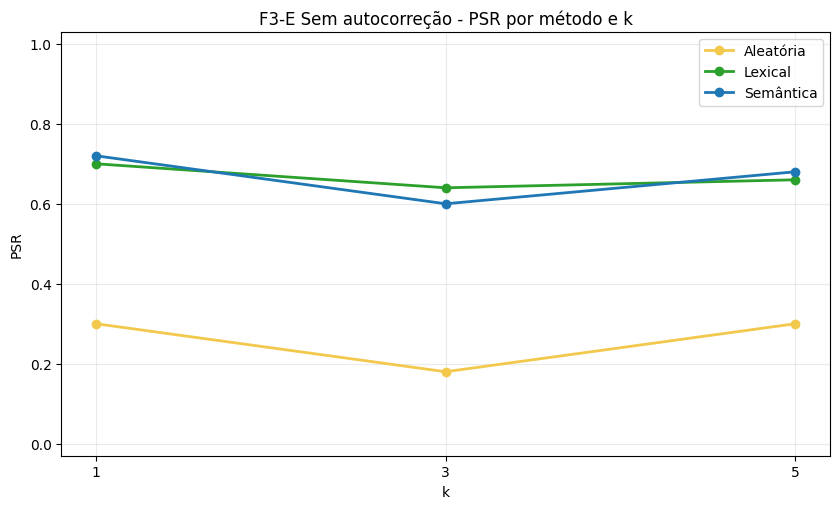

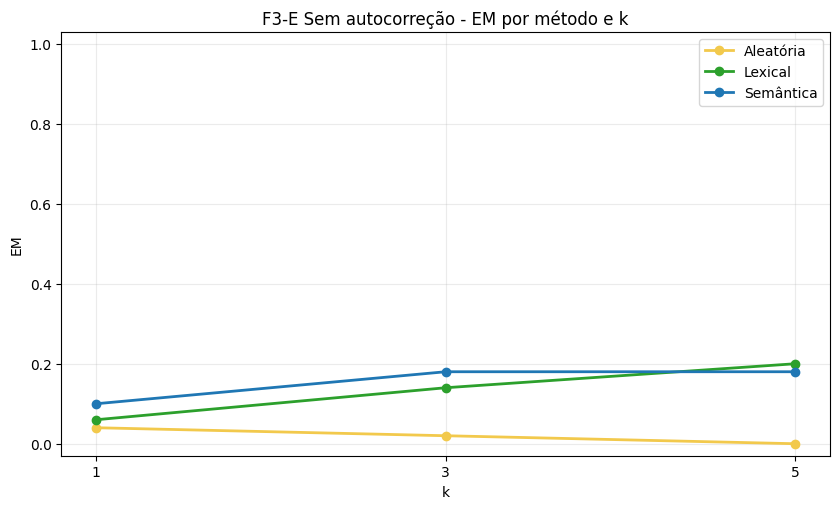

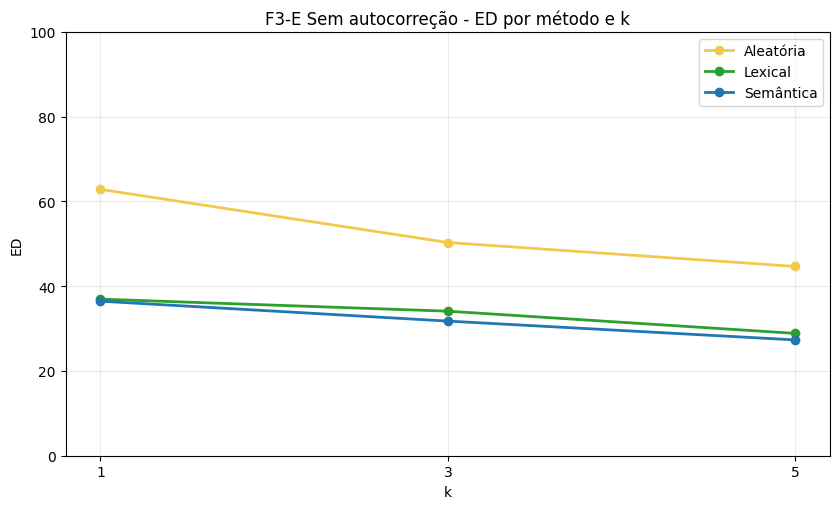

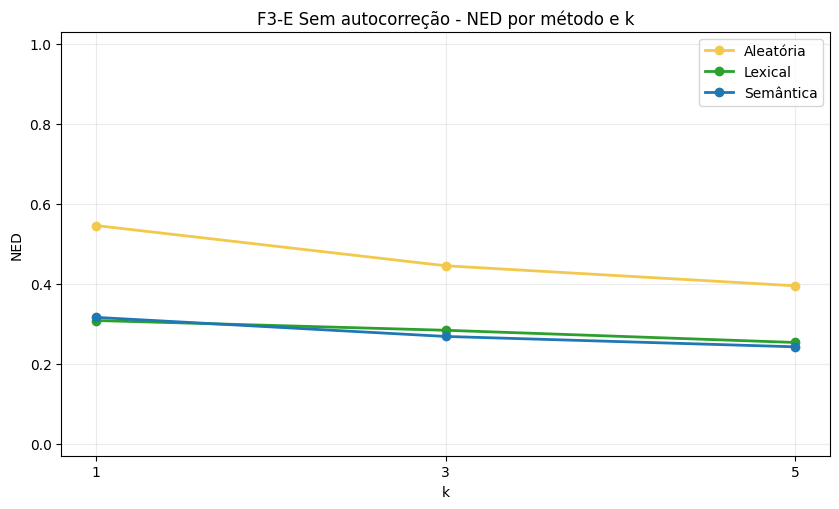

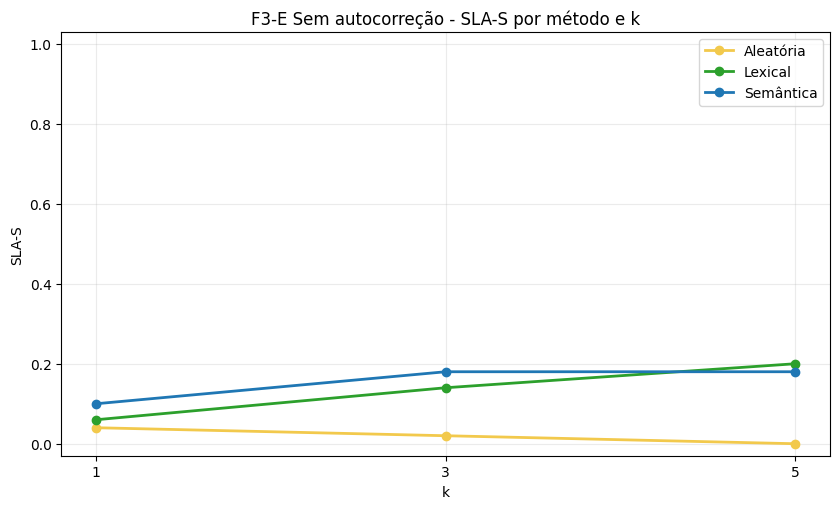

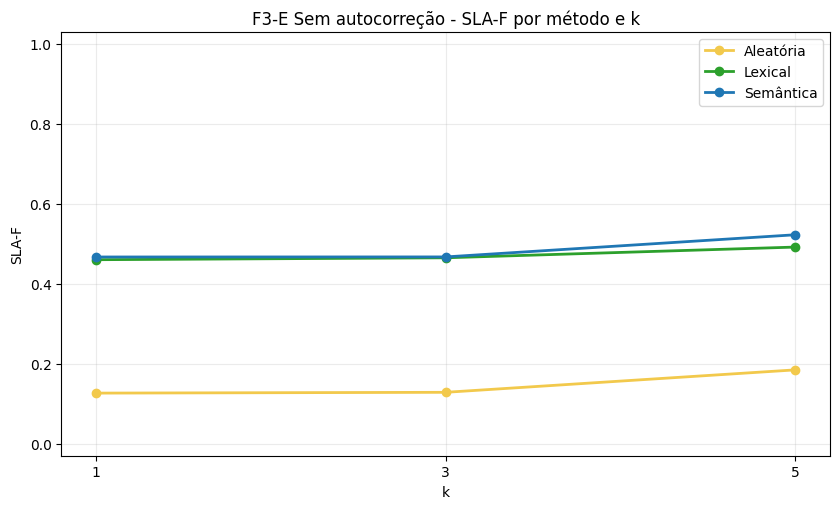

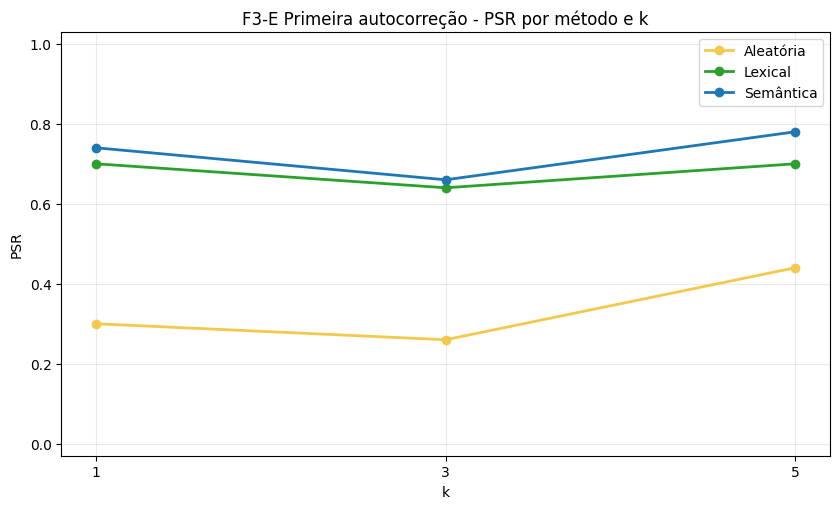

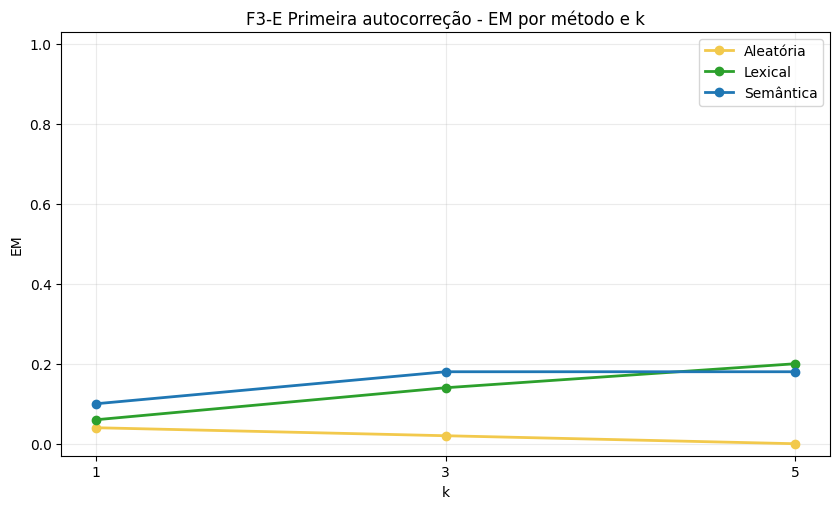

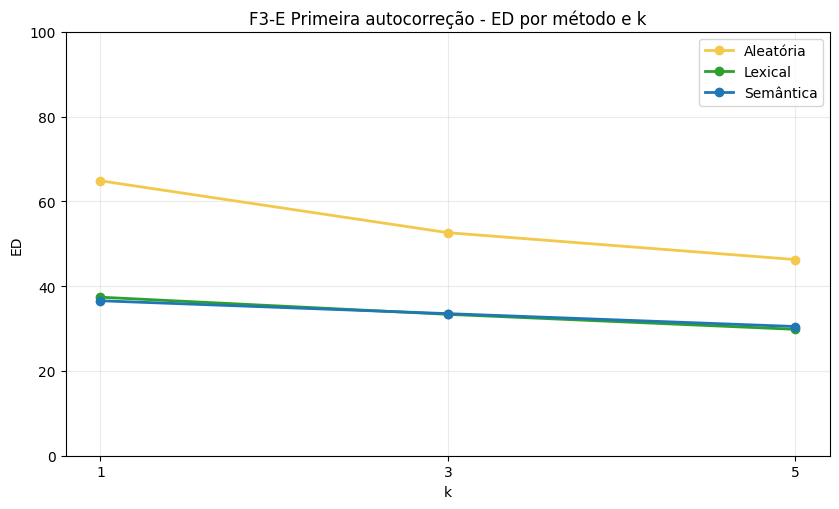

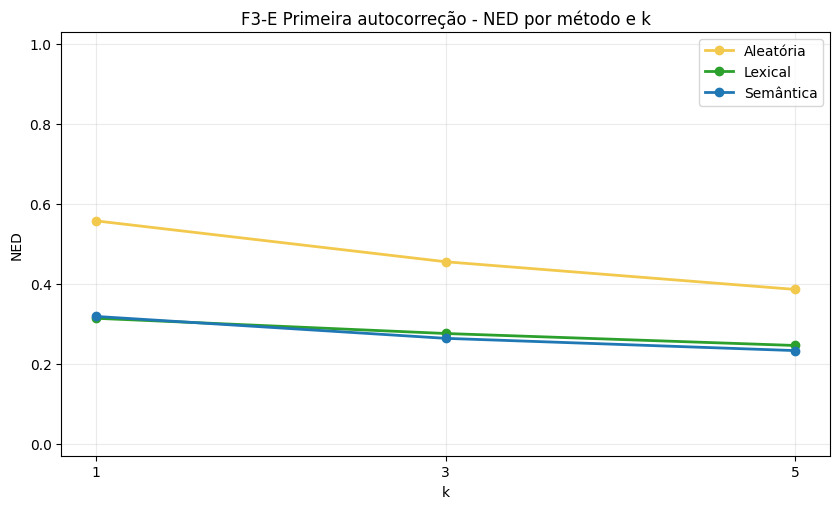

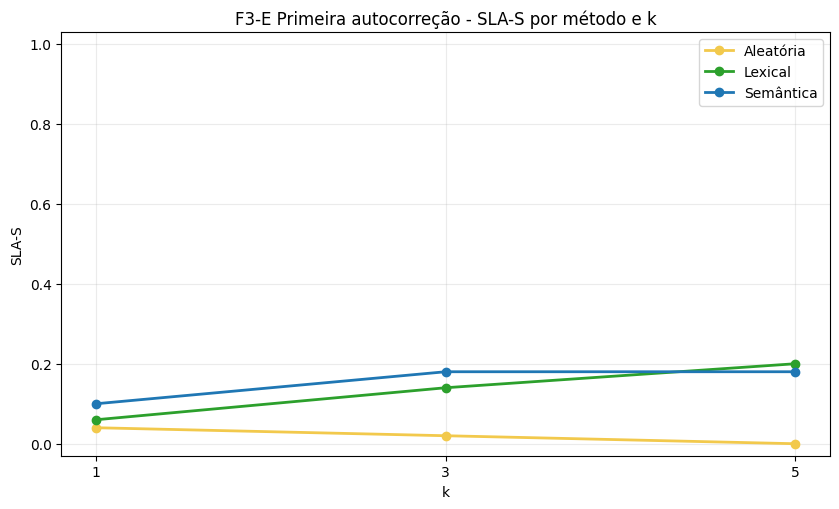

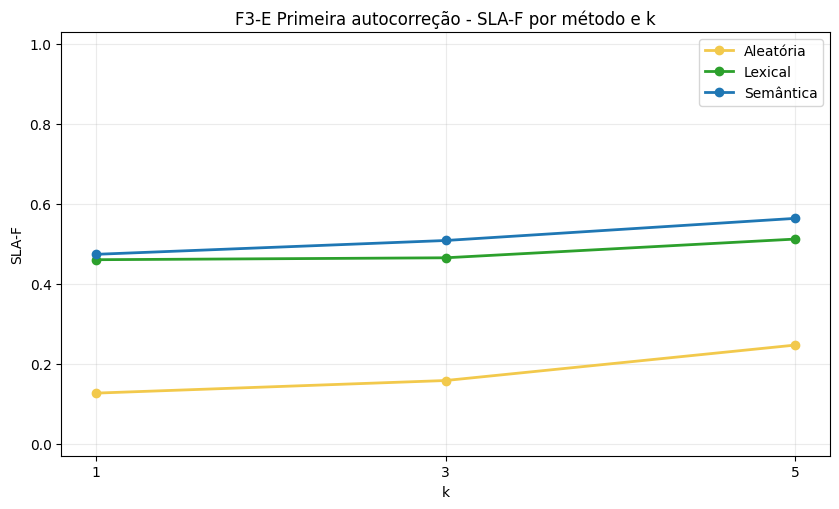

Bloco 9 concluído.
Condições resumidas: 18
Gráficos produzidos: 12
Escalas fixas aplicadas: PSR, EM, NED, SLA-S e SLA-F de 0 a 1; ED de 0 a 100.
Elegíveis à autocorreção final por PSR=0: 189
Status: OK


In [9]:
# ----------------------------------------------------------
# 9.1 Resumos por condição e por fold
# ----------------------------------------------------------

summary_df = (
    results_df.groupby(
        ["variant", "selection_method", "selection_label", "k"],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        ir_valid=("ir_valid", "sum"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
        syntax_valid=("syntax_valid", "sum"),
        autocorrection_applied=("autocorrection_applied", "sum"),
        prompt_primary_tokens=("prompt_primary_tokens", "mean"),
        prompt_secondary_tokens=("prompt_secondary_tokens", "mean"),
        prompt_autocorrection_tokens=("prompt_autocorrection_tokens", "mean"),
        generated_primary_tokens=("generated_primary_tokens", "mean"),
        generated_secondary_tokens=("generated_secondary_tokens", "mean"),
        generated_autocorrection_tokens=("generated_autocorrection_tokens", "mean"),
        elapsed_primary_seconds=("elapsed_primary_seconds", "mean"),
        elapsed_secondary_seconds=("elapsed_secondary_seconds", "mean"),
        elapsed_autocorrection_seconds=("elapsed_autocorrection_seconds", "mean"),
    )
    .reset_index()
)
summary_df["_ordem_variante"] = summary_df["variant"].map(ORDEM_VARIANTES_MAPA)
summary_df["_ordem_metodo"] = summary_df["selection_method"].map(ORDEM_METODOS_MAPA)
summary_df = (
    summary_df
    .sort_values(["_ordem_variante", "k", "_ordem_metodo"])
    .drop(columns=["_ordem_variante", "_ordem_metodo"])
    .reset_index(drop=True)
)
summary_df.to_csv(SUMMARY_PATH, index=False, encoding="utf-8")

summary_fold_df = (
    results_df.groupby(
        ["fold", "variant", "selection_method", "selection_label", "k"],
        dropna=False,
    )
    .agg(
        records=("id", "count"),
        ir_valid=("ir_valid", "sum"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
    )
    .reset_index()
)
summary_fold_df["_ordem_variante"] = summary_fold_df["variant"].map(ORDEM_VARIANTES_MAPA)
summary_fold_df["_ordem_metodo"] = summary_fold_df["selection_method"].map(ORDEM_METODOS_MAPA)
summary_fold_df = (
    summary_fold_df
    .sort_values(["fold", "_ordem_variante", "k", "_ordem_metodo"])
    .drop(columns=["_ordem_variante", "_ordem_metodo"])
    .reset_index(drop=True)
)
summary_fold_df.to_csv(SUMMARY_FOLD_PATH, index=False, encoding="utf-8")

ir_summary_df = (
    ir_validation_df.groupby(["selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        ir_extracted=("ir_extracted", "sum"),
        ir_valid=("ir_valid", "sum"),
    )
    .reset_index()
)
ir_summary_df["ir_valid_rate"] = ir_summary_df["ir_valid"] / ir_summary_df["records"]
ir_summary_df["_ordem_metodo"] = ir_summary_df["selection_method"].map(ORDEM_METODOS_MAPA)
ir_summary_df = (
    ir_summary_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
ir_summary_df.to_csv(IR_SUMMARY_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 9.2 Saídas inválidas, comparação e ganhos
# ----------------------------------------------------------

invalid_sem_ac_df = results_df.loc[
    (results_df["variant"] == "sem_ac")
    & (~results_df["syntax_valid"].astype(bool))
].copy()
invalid_primeira_ac_df = results_df.loc[
    (results_df["variant"] == "primeira_ac")
    & (~results_df["syntax_valid"].astype(bool))
].copy()

for frame in [invalid_sem_ac_df, invalid_primeira_ac_df]:
    frame["_ordem_metodo"] = frame["selection_method"].map(ORDEM_METODOS_MAPA)
    frame.sort_values(["fold", "k", "_ordem_metodo", "id"], inplace=True)
    frame.drop(columns="_ordem_metodo", inplace=True)

invalid_sem_ac_df.to_csv(INVALID_SEM_AC_PATH, index=False, encoding="utf-8")
invalid_primeira_ac_df.to_csv(INVALID_PRIMEIRA_AC_PATH, index=False, encoding="utf-8")

final_ac_eligible_df = results_df.loc[
    (results_df["variant"] == "primeira_ac")
    & (results_df["psr"] == 0)
].copy()
final_ac_eligible_df["_ordem_metodo"] = final_ac_eligible_df["selection_method"].map(ORDEM_METODOS_MAPA)
final_ac_eligible_df = (
    final_ac_eligible_df
    .sort_values(["fold", "k", "_ordem_metodo", "id"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
final_ac_eligible_df.to_csv(FINAL_AC_ELIGIBLE_PATH, index=False, encoding="utf-8")

gains_df = (
    comparison_df.groupby(["selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        autocorrections=("autocorrection_applied", "sum"),
        syntax_recovered=("syntax_recovered", "sum"),
        psr_before=("psr_before", "mean"),
        psr_after=("psr_after", "mean"),
        em_before=("em_before", "mean"),
        em_after=("em_after", "mean"),
        ed_before=("ed_before", "mean"),
        ed_after=("ed_after", "mean"),
        ned_before=("ned_before", "mean"),
        ned_after=("ned_after", "mean"),
        sla_s_before=("sla_s_before", "mean"),
        sla_s_after=("sla_s_after", "mean"),
        sla_f_before=("sla_f_before", "mean"),
        sla_f_after=("sla_f_after", "mean"),
    )
    .reset_index()
)
for metric in METRICAS:
    gains_df[f"delta_{metric}"] = gains_df[f"{metric}_after"] - gains_df[f"{metric}_before"]
gains_df["_ordem_metodo"] = gains_df["selection_method"].map(ORDEM_METODOS_MAPA)
gains_df = (
    gains_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
gains_df.to_csv(GAINS_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 9.3 Análise por exemplo e auditoria de execução
# ----------------------------------------------------------

analysis_long_df = (
    results_df.groupby(["id", "variant"], dropna=False)
    .agg(
        records=("k", "count"),
        ir_valid_rate=("ir_valid", "mean"),
        psr=("psr", "mean"),
        em=("em", "mean"),
        ed=("ed", "mean"),
        ned=("ned", "mean"),
        sla_s=("sla_s", "mean"),
        sla_f=("sla_f", "mean"),
    )
    .reset_index()
)
analysis_example_df = analysis_long_df.pivot(index="id", columns="variant")
analysis_example_df.columns = [f"{metric}_{variant}" for metric, variant in analysis_example_df.columns]
analysis_example_df = analysis_example_df.reset_index().sort_values("id").reset_index(drop=True)
analysis_example_df.to_csv(ANALYSIS_EXAMPLE_PATH, index=False, encoding="utf-8")

execution_audit_df = (
    comparison_df.groupby(["selection_method", "selection_label", "k"], dropna=False)
    .agg(
        records=("id", "count"),
        ir_valid=("ir_valid", "sum"),
        syntax_valid_before=("psr_before", "sum"),
        syntax_valid_after=("psr_after", "sum"),
        autocorrections=("autocorrection_applied", "sum"),
        syntax_recovered=("syntax_recovered", "sum"),
    )
    .reset_index()
)
execution_audit_df["_ordem_metodo"] = execution_audit_df["selection_method"].map(ORDEM_METODOS_MAPA)
execution_audit_df = (
    execution_audit_df
    .sort_values(["k", "_ordem_metodo"])
    .drop(columns="_ordem_metodo")
    .reset_index(drop=True)
)
execution_audit_df.to_csv(EXECUTION_AUDIT_PATH, index=False, encoding="utf-8")


# ----------------------------------------------------------
# 9.4 Tabelas principais
# ----------------------------------------------------------

summary_sem_df = summary_df.loc[summary_df["variant"] == "sem_ac"].copy()
summary_ac_df = summary_df.loc[summary_df["variant"] == "primeira_ac"].copy()

exibir_tabela(ir_summary_df, "Validade das IRs por método e k")
exibir_tabela(summary_sem_df, "Desempenho da F3-E sem autocorreção")
exibir_tabela(summary_ac_df, "Desempenho da F3-E com primeira autocorreção")
exibir_tabela(gains_df, "Ganhos da primeira autocorreção", altura_px=420)
exibir_tabela(summary_fold_df, "Desempenho por fold, variante, método e k", altura_px=520)


# ----------------------------------------------------------
# 9.5 Gráficos das métricas
# ----------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

LIMITES_EIXO_Y = {
    "psr": (-0.03, 1.03),
    "em": (-0.03, 1.03),
    "ed": (0.0, 100.0),
    "ned": (-0.03, 1.03),
    "sla_s": (-0.03, 1.03),
    "sla_f": (-0.03, 1.03),
}

TICKS_EIXO_Y = {
    "psr": np.arange(0.0, 1.01, 0.2),
    "em": np.arange(0.0, 1.01, 0.2),
    "ed": np.arange(0.0, 100.1, 20.0),
    "ned": np.arange(0.0, 1.01, 0.2),
    "sla_s": np.arange(0.0, 1.01, 0.2),
    "sla_f": np.arange(0.0, 1.01, 0.2),
}


# ----------------------------------------------------------
# 9.5.1 Auditoria dos limites fixos
# ----------------------------------------------------------

auditoria_limites = []

for metric in METRICAS:
    limite_inferior, limite_superior = LIMITES_EIXO_Y[metric]
    valor_minimo = float(summary_df[metric].min())
    valor_maximo = float(summary_df[metric].max())

    dentro_do_limite = (
        valor_minimo >= limite_inferior
        and valor_maximo <= limite_superior
    )

    auditoria_limites.append({
        "métrica": ROTULOS_METRICAS[metric],
        "mínimo observado": valor_minimo,
        "máximo observado": valor_maximo,
        "limite inferior": limite_inferior,
        "limite superior": limite_superior,
        "dentro do limite": dentro_do_limite,
    })

auditoria_limites_df = pd.DataFrame(auditoria_limites)

if not auditoria_limites_df["dentro do limite"].all():
    metricas_fora = auditoria_limites_df.loc[
        ~auditoria_limites_df["dentro do limite"],
        "métrica",
    ].astype(str).tolist()

    raise ValueError(
        "Há métricas fora dos limites gráficos padronizados: "
        + ", ".join(metricas_fora)
        + ". Os limites devem ser revistos de forma global para "
        "todas as estratégias antes da geração dos gráficos."
    )

exibir_tabela(
    auditoria_limites_df,
    "Auditoria dos limites fixos dos gráficos",
)


# ----------------------------------------------------------
# 9.5.2 Geração dos gráficos padronizados
# ----------------------------------------------------------

GRAFICOS_PATHS = {}

for variant in ORDEM_VARIANTES_EXIBICAO:
    variant_df = summary_df.loc[
        summary_df["variant"] == variant
    ].copy()

    for metric in METRICAS:
        fig, ax = plt.subplots(figsize=(8.5, 5.2))

        for method in ORDEM_METODOS_EXIBICAO:
            method_df = (
                variant_df.loc[
                    variant_df["selection_method"] == method
                ]
                .sort_values("k")
            )

            if method_df.empty:
                continue

            ax.plot(
                method_df["k"],
                method_df[metric],
                marker="o",
                linewidth=2,
                label=ROTULOS_METODOS[method],
                color=CORES_METODOS[method],
            )

        ax.set_title(
            f"F3-E {ROTULOS_VARIANTES[variant]} - "
            f"{ROTULOS_METRICAS[metric]} por método e k"
        )
        ax.set_xlabel("k")
        ax.set_ylabel(ROTULOS_METRICAS[metric])
        ax.set_xticks(K_FEWSHOT)

        limite_inferior, limite_superior = LIMITES_EIXO_Y[metric]
        ax.set_ylim(limite_inferior, limite_superior)
        ax.set_yticks(TICKS_EIXO_Y[metric])

        ax.grid(True, alpha=0.25)
        ax.legend()
        fig.tight_layout()

        graph_path = (
            GRAFICOS_DIR
            / f"f3e_{variant}_{metric}.png"
        )
        fig.savefig(
            graph_path,
            dpi=160,
            bbox_inches="tight",
        )
        plt.show()
        plt.close(fig)

        GRAFICOS_PATHS[(variant, metric)] = graph_path


print("Bloco 9 concluído.")
print(f"Condições resumidas: {len(summary_df)}")
print(f"Gráficos produzidos: {len(GRAFICOS_PATHS)}")
print(
    "Escalas fixas aplicadas: "
    "PSR, EM, NED, SLA-S e SLA-F de 0 a 1; "
    "ED de 0 a 100."
)
print(
    "Elegíveis à autocorreção final por PSR=0: "
    f"{len(final_ac_eligible_df)}"
)
print("Status: OK")

## Bloco 10 - Barreiras finais, manifesto e empacotamento

### Objetivo

Este bloco encerra a F3-E e cria o pacote operacional utilizado na consolidação e na autocorreção final.

### Barreiras quantitativas

A execução oficial exige:

- 450 fluxos planejados;
- 450 prompts e gerações NL + R1 → IR;
- 450 prompts e gerações IR + R2 → Nile;
- autocorreções em quantidade idêntica às Nile iniciais com `PSR=0`;
- 900 resultados finais;
- 18 condições de 50 registros;
- 90 combinações por fold;
- 50 IDs na análise por exemplo;
- doze gráficos.

### Barreiras de consistência

O bloco confirma:

- igualdade entre tokens auditados e tokens registrados na inferência;
- limite de contexto em todos os estágios;
- conformidade dos 900 registros com o JSON Schema;
- duas variantes para cada fluxo-base;
- preservação exata da Nile e das métricas quando nenhuma autocorreção foi aplicada;
- mesma IR gerada nas duas variantes;
- ausência da R1 e da R2 do teste nos prompts;
- nenhuma exposição de referência;
- hashes de todos os artefatos.

### Manifesto

O manifesto registra explicitamente que:

- a IR é gerada pelo modelo aluno;
- R1 é utilizada somente nas demonstrações do primeiro estágio;
- R2 é utilizada somente nas demonstrações do segundo estágio e da autocorreção;
- R3 não é utilizada;
- a IR de referência não é usada na inferência do teste;
- a primeira autocorreção atua somente sobre Nile com `PSR=0`.

### Pacote final

O arquivo produzido é:

```text
f3e_traducao_com_r1_r2.zip
```

O ZIP não contém pasta externa repetida. As saídas da variante `primeira_ac` que permanecem com `PSR=0` são registradas separadamente como candidatas à autocorreção final.

### Resultado esperado

A F3-E só é considerada concluída quando o pacote pode ser reaberto, sua estrutura corresponde ao manifesto e todos os hashes conferem.

In [10]:
# ----------------------------------------------------------
# 10.1 Barreiras finais da execução oficial
# ----------------------------------------------------------

if MODO_TESTE_RAPIDO:
    raise RuntimeError(
        "O modo de teste rápido está ativo. Desative-o e execute os Blocos 6 a 10 "
        "para produzir o pacote oficial da F3-E."
    )

if len(plan_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("O pacote oficial exige 450 fluxos-base.")
if len(prompt_ir_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("A quantidade de prompts IR é divergente.")
if len(ir_generation_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("A quantidade de gerações IR é divergente.")
if len(ir_validation_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("A quantidade de validações IR é divergente.")
if len(prompt_nile_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("A quantidade de prompts Nile é divergente.")
if len(nile_generation_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("A quantidade de gerações Nile é divergente.")
if len(initial_evaluation_records) != TOTAL_FLUXOS_BASE_ESPERADO:
    raise ValueError("A quantidade de avaliações iniciais é divergente.")

expected_autocorrections = int(initial_evaluation_df["eligible_for_autocorrection"].sum())
if len(prompt_ac_records) != expected_autocorrections:
    raise ValueError("A quantidade de prompts de autocorreção é divergente.")
if len(ac_generation_records) != expected_autocorrections:
    raise ValueError("A quantidade de gerações de autocorreção é divergente.")
if len(result_records) != TOTAL_REGISTROS_ESPERADO:
    raise ValueError("O pacote oficial exige 900 resultados.")
if len(summary_df) != TOTAL_CONDICOES_ESPERADO or not summary_df["records"].eq(50).all():
    raise ValueError("O resumo não contém 18 condições de 50 registros.")
if len(summary_fold_df) != TOTAL_FOLDS_ESPERADO * TOTAL_CONDICOES_ESPERADO:
    raise ValueError("O resumo por fold não possui 90 combinações.")
if len(ir_summary_df) != TOTAL_CONDICOES_BASE or not ir_summary_df["records"].eq(50).all():
    raise ValueError("O resumo da IR não contém nove condições de 50 registros.")
if len(analysis_example_df) != TOTAL_EXEMPLOS_ESPERADO:
    raise ValueError("A análise por exemplo deve conter 50 IDs.")
if len(GRAFICOS_PATHS) != 12:
    raise ValueError("A F3-E deve produzir doze gráficos.")


def assert_token_consistency(prompt_records_stage, generation_records_stage, max_new_tokens):
    prompt_map = {
        str(record["execution_id"]): int(record["prompt_tokens"])
        for record in prompt_records_stage
    }
    generation_map = {
        str(record["execution_id"]): int(record["prompt_tokens"])
        for record in generation_records_stage
    }
    if prompt_map != generation_map:
        raise ValueError("A auditoria de tokens diverge da inferência.")
    if prompt_map and max(prompt_map.values()) + max_new_tokens > CONTEXT_LIMIT:
        raise ValueError("Há prompt fora do limite de contexto.")


assert_token_consistency(prompt_ir_records, ir_generation_records, MAX_NEW_TOKENS_IR)
assert_token_consistency(prompt_nile_records, nile_generation_records, MAX_NEW_TOKENS_NILE)
assert_token_consistency(prompt_ac_records, ac_generation_records, MAX_NEW_TOKENS_NILE)

if results_df["status"].ne("completed").any():
    raise ValueError("Há resultados não concluídos.")
if results_df["strategy"].ne(ESTRATEGIA).any():
    raise ValueError("Há resultado associado a outra estratégia.")

for record in result_records:
    errors = sorted(result_validator.iter_errors(record), key=lambda error: list(error.path))
    if errors:
        raise ValueError("Há resultado incompatível com o schema comum.")

result_key_map = {}
for record in result_records:
    key = (
        int(record["fold"]),
        str(record["id"]),
        str(record["selection_method"]),
        int(record["k"]),
        str(record["variant"]),
    )
    if key in result_key_map:
        raise ValueError(f"Resultado duplicado para {key}.")
    result_key_map[key] = record

for plan in plan_records:
    base = (
        int(plan["fold"]),
        str(plan["id"]),
        str(plan["selection_method"]),
        int(plan["k"]),
    )
    sem = result_key_map[(*base, "sem_ac")]
    ac = result_key_map[(*base, "primeira_ac")]
    if canonical_json(sem["generated_ir"]) != canonical_json(ac["generated_ir"]):
        raise ValueError(f"A IR diverge entre variantes para {base}.")
    eligible = int(sem["psr"]) == 0
    if bool(ac["autocorrection_applied"]) != eligible:
        raise ValueError(f"Decisão de autocorreção divergente para {base}.")
    if not eligible:
        if ac["nile_evaluated"] != sem["nile_evaluated"]:
            raise ValueError(f"Saída preservada foi alterada para {base}.")
        for metric in METRICAS:
            if not np.isclose(float(ac[metric]), float(sem[metric]), rtol=0, atol=1e-12):
                raise ValueError(f"Métrica preservada foi alterada para {base}: {metric}.")

if prompt_audit_df["pending_placeholders"].astype(bool).any():
    raise ValueError("Há placeholders pendentes.")
for column in [
    "test_reference_nile_exposed",
    "test_r1_exposed",
    "test_r2_exposed",
    "test_r3_exposed",
]:
    if prompt_audit_df[column].fillna(False).astype(bool).any():
        raise ValueError(f"Há exposição de referência em {column}.")
if not prompt_audit_df["context_ok"].astype(bool).all():
    raise ValueError("Há prompt fora do contexto.")


# ----------------------------------------------------------
# 10.2 Configuração consolidada
# ----------------------------------------------------------

def stage_token_stats(token_df):
    if token_df.empty:
        return {"prompts": 0, "min": None, "max": None, "max_reserved": None}
    return {
        "prompts": int(len(token_df)),
        "min": int(token_df["prompt_tokens"].min()),
        "max": int(token_df["prompt_tokens"].max()),
        "max_reserved": int(token_df["reserved_tokens"].max()),
    }


config_final = {
    **configuracao_inicial,
    "inputs": {
        "f3_modelo_source": str(FONTE_F3_MODELO["path"]),
        "f3_modelo_source_type": FONTE_F3_MODELO["type"],
        "f3_modelo_manifest_sha256": f3_modelo_manifest_sha256,
    },
    "student_model": {
        "name": MODELO_ALUNO,
        "model_id": MODELO_HF_ID,
        "source_used": str(MODEL_SOURCE),
        "source_type": MODEL_SOURCE_TYPE,
        "device": model_device,
        "dtype": model_dtype,
        "context_limit": CONTEXT_LIMIT,
        "do_sample": DO_SAMPLE,
        "max_new_tokens_ir": MAX_NEW_TOKENS_IR,
        "max_new_tokens_nile": MAX_NEW_TOKENS_NILE,
    },
    "observed": {
        "base_pipelines": int(len(plan_records)),
        "final_results": int(len(result_records)),
        "ir_valid": int(ir_validation_df["ir_valid"].sum()),
        "nile_syntax_valid_before": int(
            results_df.loc[results_df["variant"] == "sem_ac", "syntax_valid"].sum()
        ),
        "nile_syntax_valid_after": int(
            results_df.loc[results_df["variant"] == "primeira_ac", "syntax_valid"].sum()
        ),
        "autocorrections_applied": expected_autocorrections,
        "syntax_recovered": int(comparison_df["syntax_recovered"].sum()),
        "final_autocorrection_eligible": int(len(final_ac_eligible_df)),
        "tokens": {
            "nl_to_ir": stage_token_stats(token_audit_ir_df),
            "ir_to_nile": stage_token_stats(token_audit_nile_df),
            "autocorrection": stage_token_stats(token_audit_ac_df),
        },
    },
}
write_json(config_final, CONFIG_PATH)


# ----------------------------------------------------------
# 10.3 Inventário e manifesto
# ----------------------------------------------------------

clean_runtime_caches(F3E_DIR)

package_files = [
    CONFIG_PATH,
    PLANO_PATH,
    PROMPTS_IR_PATH,
    TOKEN_AUDIT_IR_PATH,
    GENERATIONS_IR_PATH,
    IR_VALIDATION_PATH,
    PROMPTS_NILE_PATH,
    TOKEN_AUDIT_NILE_PATH,
    GENERATIONS_NILE_PATH,
    INITIAL_EVALUATION_PATH,
    PROMPTS_AC_PATH,
    TOKEN_AUDIT_AC_PATH,
    GENERATIONS_AC_PATH,
    PROMPT_AUDIT_PATH,
    RESULTS_JSONL_PATH,
    RESULTS_CSV_PATH,
    SUMMARY_PATH,
    SUMMARY_FOLD_PATH,
    IR_SUMMARY_PATH,
    INVALID_SEM_AC_PATH,
    INVALID_PRIMEIRA_AC_PATH,
    FINAL_AC_ELIGIBLE_PATH,
    ANALYSIS_EXAMPLE_PATH,
    EXECUTION_AUDIT_PATH,
    COMPARISON_PATH,
    GAINS_PATH,
    *[GRAFICOS_PATHS[(variant, metric)] for variant in ORDEM_VARIANTES_EXIBICAO for metric in METRICAS],
]

missing_files = [str(path) for path in package_files if not Path(path).is_file()]
if missing_files:
    raise FileNotFoundError("Arquivos finais ausentes: " + ", ".join(missing_files))

file_inventory = []
for path in package_files:
    path = Path(path)
    relative = (
        "graficos/" + path.name
        if path.is_relative_to(GRAFICOS_DIR)
        else path.relative_to(PACOTE_DIR).as_posix()
    )
    file_inventory.append({
        "file": relative,
        "size_bytes": int(path.stat().st_size),
        "sha256": sha256_file(path),
    })

manifest = {
    "phase": FASE,
    "strategy": ESTRATEGIA,
    "variants": VARIANTES,
    "description": NOME_ESTRATEGIA,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": DATASET,
    "inputs": {
        "f3_modelo_manifest_sha256": f3_modelo_manifest_sha256,
        "f0_manifest_sha256": f3_modelo_manifest.get("inputs", {}).get("f0_manifest_sha256"),
        "f1_manifest_sha256": f3_modelo_manifest.get("inputs", {}).get("f1_manifest_sha256"),
        "f2_manifest_sha256": f3_modelo_manifest.get("inputs", {}).get("f2_manifest_sha256"),
    },
    "experimental_design": {
        "folds": TOTAL_FOLDS_ESPERADO,
        "examples": TOTAL_EXEMPLOS_ESPERADO,
        "base_conditions": TOTAL_CONDICOES_BASE,
        "conditions": TOTAL_CONDICOES_ESPERADO,
        "base_pipelines": TOTAL_FLUXOS_BASE_ESPERADO,
        "records": TOTAL_REGISTROS_ESPERADO,
        "k_values": K_FEWSHOT,
        "selection_methods": METODOS_FEWSHOT,
        "formal_equivalent_demonstrations_excluded": True,
    },
    "model": config_final["student_model"],
    "metrics": {
        "names": ["PSR", "EM", "ED", "NED", "SLA-S", "SLA-F"],
        "internal_fields": METRICAS,
        "embedding_metric_used": False,
    },
    "method": {
        "teacher_model_used": False,
        "fine_tuning_used": False,
        "intermediate_representation_used": True,
        "reference_ir_used_for_test_inference": False,
        "generated_ir_used_for_secondary_stage": True,
        "generated_ir_replaced_when_invalid": False,
        "rationales_used_in_prompt": True,
        "r1_used_in_primary_stage": True,
        "r2_used_in_secondary_stage": True,
        "r3_used_in_prompt": False,
        "autocorrection_used": True,
        "autocorrection_attempt": 1,
        "autocorrection_only_for_syntax_invalid_nile": True,
        "ir_autocorrection_used": False,
        "same_few_shot_ids_across_stages": True,
        "test_reference_exposed": False,
        "checkpoint_resume_enabled": True,
    },
    "results": {
        "ir_valid": int(ir_validation_df["ir_valid"].sum()),
        "autocorrections_applied": expected_autocorrections,
        "syntax_valid_before": config_final["observed"]["nile_syntax_valid_before"],
        "syntax_valid_after": config_final["observed"]["nile_syntax_valid_after"],
        "syntax_recovered": config_final["observed"]["syntax_recovered"],
        "final_autocorrection_eligible": config_final["observed"]["final_autocorrection_eligible"],
        "summary": summary_df.to_dict(orient="records"),
    },
    "environment": {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "packages": {
            "torch": package_version("torch"),
            "transformers": package_version("transformers"),
            "accelerate": package_version("accelerate"),
            "pandas": package_version("pandas"),
            "numpy": package_version("numpy"),
            "lark": package_version("lark"),
            "jsonschema": package_version("jsonschema"),
            "matplotlib": package_version("matplotlib"),
            "tqdm": package_version("tqdm"),
        },
    },
    "files": file_inventory,
}
write_json(manifest, MANIFEST_PATH)


# ----------------------------------------------------------
# 10.4 Criação e verificação do ZIP
# ----------------------------------------------------------

if ZIP_FINAL_PATH.exists():
    ZIP_FINAL_PATH.unlink()

with zipfile.ZipFile(ZIP_FINAL_PATH, "w", compression=zipfile.ZIP_DEFLATED) as package:
    for path, item in zip(package_files, file_inventory):
        package.write(path, arcname=item["file"])
    package.write(MANIFEST_PATH, arcname="manifest.json")

with zipfile.ZipFile(ZIP_FINAL_PATH, "r") as package:
    members = [name for name in package.namelist() if not name.endswith("/")]
    expected_members = [item["file"] for item in file_inventory] + ["manifest.json"]
    if sorted(members) != sorted(expected_members):
        raise ValueError("A estrutura do ZIP diverge do manifesto.")

    manifest_zip = json.loads(package.read("manifest.json").decode("utf-8"))
    for item in manifest_zip["files"]:
        payload = package.read(item["file"])
        if len(payload) != int(item["size_bytes"]):
            raise ValueError(f"Tamanho divergente no ZIP: {item['file']}.")
        if hashlib.sha256(payload).hexdigest() != item["sha256"]:
            raise ValueError(f"Hash divergente no ZIP: {item['file']}.")

final_summary_df = pd.DataFrame([
    {"item": "fluxos-base", "value": len(plan_records), "status": "OK"},
    {"item": "resultados finais", "value": len(result_records), "status": "OK"},
    {"item": "IRs válidas", "value": int(ir_validation_df["ir_valid"].sum()), "status": "OK"},
    {"item": "autocorreções aplicadas", "value": expected_autocorrections, "status": "OK"},
    {"item": "elegíveis à autocorreção final", "value": len(final_ac_eligible_df), "status": "OK"},
    {"item": "arquivos no ZIP", "value": len(expected_members), "status": "OK"},
])

exibir_tabela(final_summary_df, "Resumo final da F3-E")

print("Bloco 10 concluído.")
print(f"Pacote final: {ZIP_FINAL_PATH}")
print(f"Arquivos no ZIP: {len(expected_members)}")
print("Manifesto e hashes: confirmados")
print("F3-E concluída e pronta para auditoria pós-execução.")
print("Status: OK")

item,valor,status
fluxos-base,450,OK
resultados finais,900,OK
IRs válidas,230,OK
autocorreções aplicadas,211,OK
elegíveis à autocorreção final,189,OK
arquivos no ZIP,39,OK


Bloco 10 concluído.
Pacote final: /kaggle/working/f3e_traducao_com_r1_r2.zip
Arquivos no ZIP: 39
Manifesto e hashes: confirmados
F3-E concluída e pronta para auditoria pós-execução.
Status: OK
